# Exploración de la base de datos SaberPro (2021-2024)
Este notebook realiza una exploración inicial de la base de datos SQLite `SaberPro2021_2024.db`.
Incluye:
- Resumen de las tablas
- Distribución de variables clave (género, etnia)
- Estadísticas descriptivas de puntajes
- Visualizaciones de relaciones entre puntajes
- Evolución de los puntajes promedio por año


## Análisis Univariado

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy import stats
import prince


# Estilos de gráficos
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

In [ ]:
# Conectar con la base de datos
nombre_db = "SaberPro2021_2024.db"
try:
    conn = sqlite3.connect(nombre_db)
    cursor = conn.cursor()
    print(f"Conexión exitosa con {nombre_db}")
except Exception as e:
    print("Error al conectar con la base de datos:", e)

Conexión exitosa con SaberPro2021_2024.db


In [ ]:
# Listado de tablas a explorar
tables = ["dim_estudiante", "dim_institucion", "dim_programa", "dim_tiempo", "dim_familia", "fact_resultados"]

for t in tables:
    try:
        df = pd.read_sql(f"SELECT * FROM {t}", conn)
        print(f"\nTabla: {t}")
        print("Registros totales:", len(df))
        print("Columnas:", list(df.columns))
    except Exception as e:
        print(f"Error al leer la tabla {t}:", e)


Tabla: dim_estudiante
Registros totales: 1015295
Columnas: ['id_estudiante', 'estu_consecutivo', 'estu_tipodocumento', 'estu_genero', 'estu_etnia', 'estu_nacionalidad', 'estu_fechanacimiento', 'estu_estudiante', 'estu_cursoiesexterna', 'estu_horassemanatrabaja']

Tabla: dim_institucion
Registros totales: 275
Columnas: ['id_institucion', 'inst_cod_institucion', 'inst_nombre_institucion', 'inst_departamento', 'inst_municipio', 'inst_caracter_academico', 'inst_origen']

Tabla: dim_programa
Registros totales: 4803
Columnas: ['id_programa', 'estu_snies_prgmacademico', 'estu_prgm_academico', 'estu_nivel_prgm_academico', 'estu_metodo_prgm', 'estu_nucleo_pregrado']

Tabla: dim_tiempo
Registros totales: 14
Columnas: ['id_tiempo', 'periodo', 'anio']

Tabla: dim_familia
Registros totales: 1015295
Columnas: ['id_familia', 'estu_consecutivo', 'fami_estratovivienda', 'fami_educacionpadre', 'fami_educacionmadre', 'fami_ocupacionpadre', 'fami_ocupacionmadre', 'fami_tieneinternet', 'fami_tienecomputad

In [ ]:
# Verificación de metadatos y nulos

fact = pd.read_sql("SELECT * FROM fact_resultados", conn)
resumen = pd.DataFrame({
    "tipo_dato": fact.dtypes,
    "nulos": fact.isnull().sum(),
    "duplicados": fact.duplicated().sum()
})

print("Resumen de calidad de datos:")
print(resumen)

Resumen de calidad de datos:
                          tipo_dato  nulos  duplicados
id_resultado                  int64      0           0
id_estudiante                 int64      0           0
id_institucion              float64  27478           0
id_programa                 float64  27480           0
id_familia                    int64      0           0
id_tiempo                     int64      0           0
mod_competen_ciudada_punt   float64      0           0
mod_comuni_escrita_punt     float64      0           0
mod_ingles_punt             float64    573           0
mod_lectura_critica_punt    float64      0           0
mod_razona_cuantitat_punt   float64      0           0


Districución de género ♀️♂️


Distribución de género:
estu_genero
F    588790
M    426486
Name: count, dtype: int64


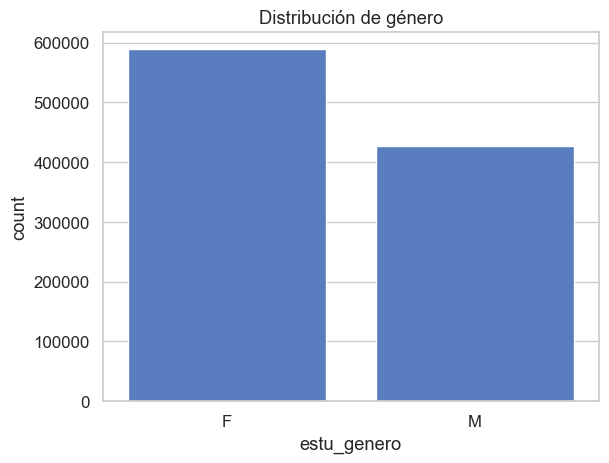

In [ ]:
# Distribución de género en estudiantes (excluyendo 'L')
dim_estudiante = pd.read_sql("SELECT * FROM dim_estudiante WHERE estu_genero <> 'L'", conn)

print("\nDistribución de género:")
print(dim_estudiante["estu_genero"].value_counts(dropna=True))

sns.countplot(data=dim_estudiante, x="estu_genero",
              order=dim_estudiante["estu_genero"].value_counts().index)
plt.title("Distribución de género")
plt.show()

En el grupo de estudiantes que presentó el Saber Pro entre 2021 y 2024 vemos que participaron más mujeres que hombres. De 1.015.276 personas, 588.790 son mujeres aproximadamente un 58% y 426.486 son hombres aproximadamente un 42%. Esto quiere decir que, en estos años, las mujeres fueron mayoría entre quienes presentaron el examen.

Distribución por etnia 👧🏻👦🏽🧒🏿


Distribución de etnia:
estu_etnia
Afrodescendiente                 22430
Zenu (Senu)                       3322
Pasto                             2561
Otro grupo étnico minoritario     2496
Wayúu                             2262
Raizal                            1209
Tikuna                            1143
Paez (Autodenominacion Nasa)      1139
Pijao                              910
Negritudes                         829
Name: count, dtype: int64


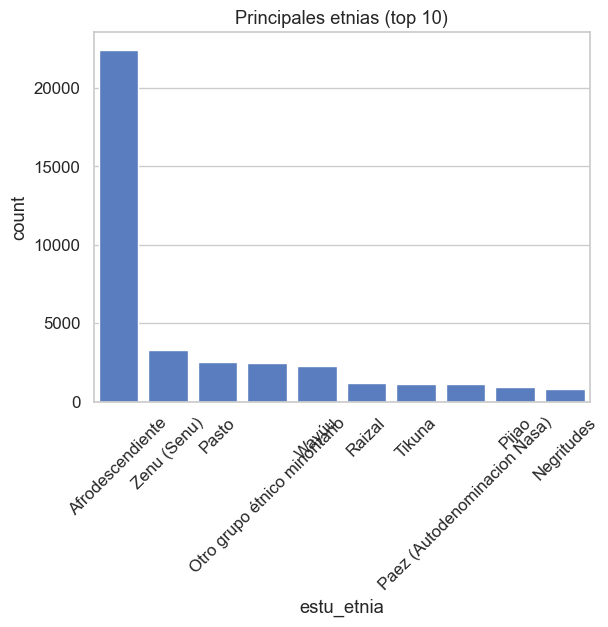

In [ ]:
# Distribución de etnia (excluyendo 'Ninguno')
print("\nDistribución de etnia:")
print(dim_estudiante[dim_estudiante["estu_etnia"] != 'Ninguno']["estu_etnia"].value_counts(dropna=True).head(10))

sns.countplot(data=dim_estudiante[dim_estudiante["estu_etnia"] != 'Ninguno'],
              x="estu_etnia",
              order=dim_estudiante[dim_estudiante["estu_etnia"] != 'Ninguno']["estu_etnia"].value_counts().head(10).index)
plt.title("Principales etnias (top 10)")
plt.xticks(rotation=45)
plt.show()

En la distribución por etnia del Saber Pro 2021–2024, el grupo afrodescendiente es el de mayor presencia, con 22.430 estudiantes. Esto muestra una fuerte concentración en este grupo frente a los demás. Muy por detrás aparecen Zenú (3.322), Pasto (2.561), “Otro grupo étnico minoritario” (2.496) y Wayúu (2.262). Con esto podemos observar que la participacion etnica no está distribuida de forma pareja, pues el grupo afrodescendiente reúne la mayoría de los casos reportados, mientras que el resto se reparte en cantidades mucho más pequeñas.

Estadísticas descriptivas de los puntajes 📊

In [ ]:
# Estadísticas descriptivas de los puntajes

print("\nEstadísticas descriptivas de los puntajes:")
print(fact[[
    "mod_competen_ciudada_punt", "mod_comuni_escrita_punt",
    "mod_ingles_punt", "mod_lectura_critica_punt",
    "mod_razona_cuantitat_punt"
]].describe().map(lambda x: f"{x:.0f}" if float(x).is_integer() else f"{x:.2f}"))


Estadísticas descriptivas de los puntajes:
      mod_competen_ciudada_punt mod_comuni_escrita_punt mod_ingles_punt  \
count                   1015295                 1015295         1014722   
mean                     142.84                  135.17          154.04   
std                       34.35                   44.59           34.40   
min                           0                       0               0   
25%                         118                     121             132   
50%                         143                     141             151   
75%                         168                     162             175   
max                         300                     300             300   

      mod_lectura_critica_punt mod_razona_cuantitat_punt  
count                  1015295                   1015295  
mean                    149.26                    143.53  
std                      31.06                     32.51  
min                          0              

En estos años, el módulo con mejores resultados es Inglés con un promedio cerca de 154 puntos. Después vienen Lectura Crítica (alrededor de 149), Razonamiento Cuantitativo (144) y Competencias Ciudadanas (143). El más bajo es Comunicación Escrita, con un promedio de unos 135 puntos. Entre Inglés y Comunicación Escrita hay una diferencia grande, casi 19 puntos, así que valdría la pena poner atención especial a fortalecer Escritura.

Si vemos cómo se reparten los puntajes, Lectura Crítica es el módulo donde los resultados son más parecidos entre estudiantes esto significa menos diferencia entre altos y bajos. En cambio, Comunicación Escrita es donde hay más distancia: conviven muchos puntajes muy altos y muy bajos. La mitad de los estudiantes se ubica más o menos en estos rangos:

- Inglés 132–175
- Lectura Crítica 127–172
- Razonamiento Cuantitativo 120–166
- Competencias Ciudadanas 118–168
- Comunicación Escrita 121–162

Relaciones entre puntajes 📉📈

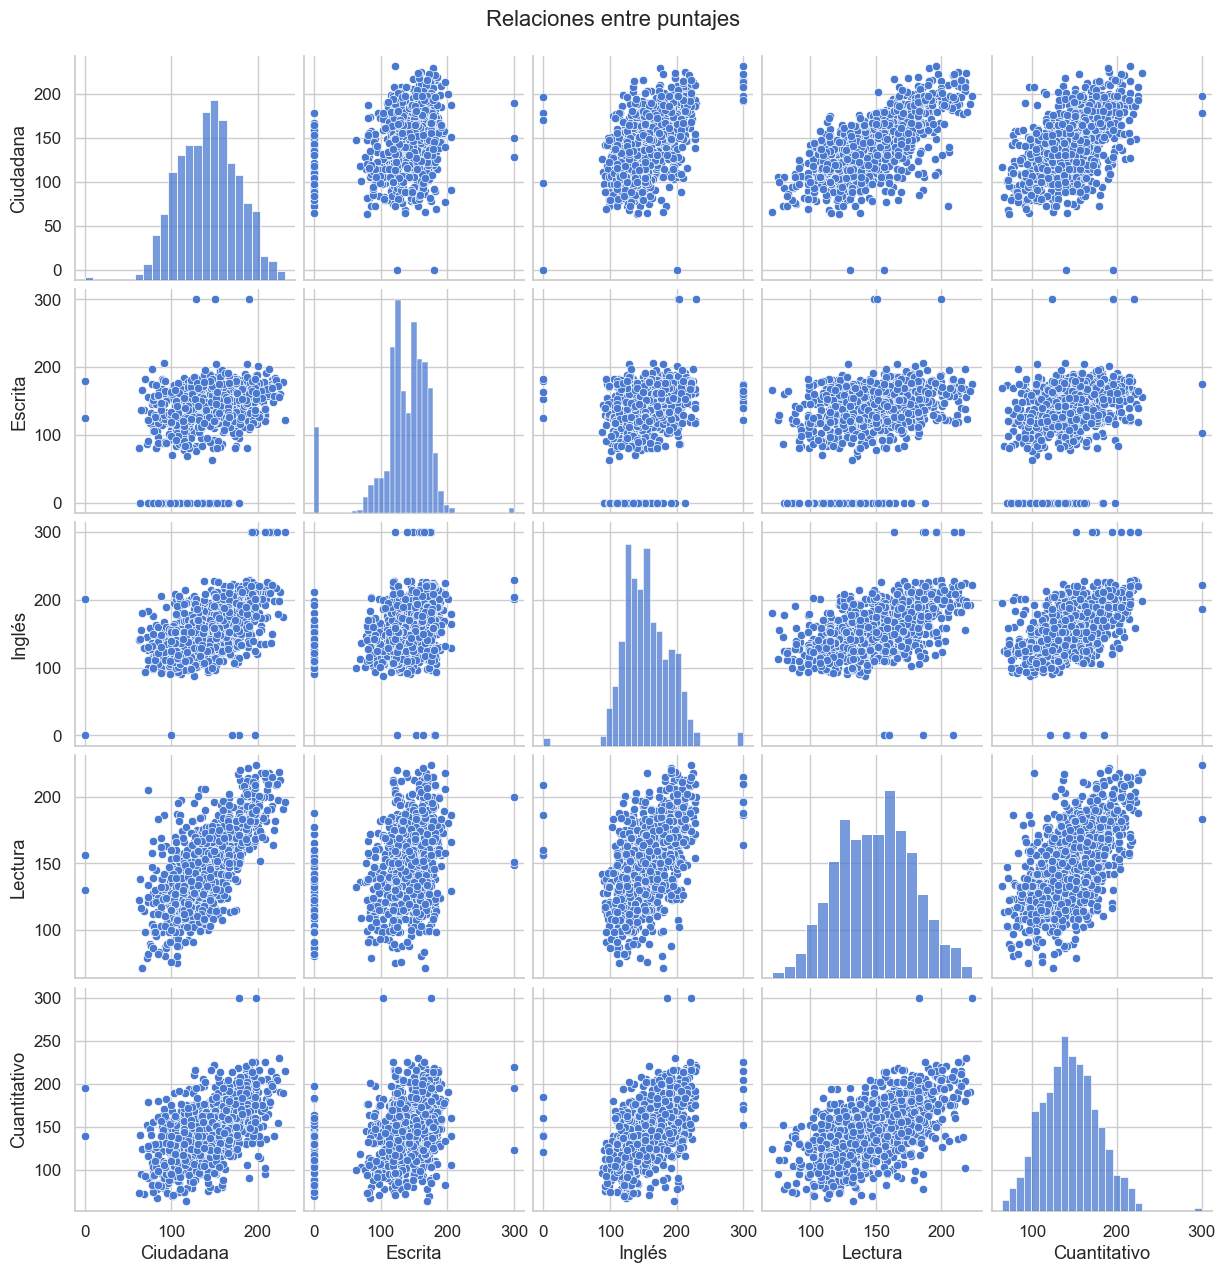

In [ ]:
# Visualización de relaciones entre puntajes (muestra de 500)
sns.pairplot(fact[[
    "mod_competen_ciudada_punt", "mod_comuni_escrita_punt",
    "mod_ingles_punt", "mod_lectura_critica_punt",
    "mod_razona_cuantitat_punt"
]].rename(columns={
    "mod_competen_ciudada_punt": "Ciudadana",
    "mod_comuni_escrita_punt": "Escrita",
    "mod_ingles_punt": "Inglés",
    "mod_lectura_critica_punt": "Lectura",
    "mod_razona_cuantitat_punt": "Cuantitativo"
}).sample(1000, random_state=42))

plt.suptitle("Relaciones entre puntajes", y=1.02)
plt.show()

Con más de 1 millón de registros, los promedios se ubican así: Inglés ~154, Lectura Crítica ~149, Razonamiento Cuantitativo ~144, Competencias Ciudadanas ~143 y Comunicación Escrita ~135 siendo este el más bajo. En términos de variación, Comunicación Escrita es donde los resultados están más dispersos (hay más diferencia entre quienes les va muy bien y muy mal), mientras que Lectura Crítica es el módulo más parejo. Las distribuciones de todos los módulos se concentran alrededor de la mitad de la escala y caen hacia los extremos, aparecen algunos ceros, que probablemente corresponden a casos atípicos o registros especiales.

Evolución por año (Saber Pro 2021–2024) 📉📈

In [ ]:
# Cruce: Puntaje global por año
query = '''
SELECT t.anio,
       AVG(f.mod_competen_ciudada_punt) AS avg_ciudadana,
       AVG(f.mod_comuni_escrita_punt) AS avg_comunicacion,
       AVG(f.mod_ingles_punt) AS avg_ingles,
       AVG(f.mod_lectura_critica_punt) AS avg_lectura,
       AVG(f.mod_razona_cuantitat_punt) AS avg_razonamiento
FROM fact_resultados f
JOIN dim_tiempo t ON f.id_tiempo = t.id_tiempo
GROUP BY t.anio
ORDER BY t.anio;
'''
df_year = pd.read_sql(query, conn)
print("\nPromedios de puntaje por año:")
print(df_year)



Promedios de puntaje por año:
   anio  avg_ciudadana  avg_comunicacion  avg_ingles  avg_lectura  \
0  2021     143.068609        137.173516  153.579383   145.653312   
1  2022     143.428343        129.207653  154.694540   150.218158   
2  2023     139.372395        140.405398  152.874263   148.783899   
3  2024     145.224484        133.641915  154.964503   152.155848   

   avg_razonamiento  
0        143.337535  
1        145.075943  
2        142.600752  
3        143.268120  


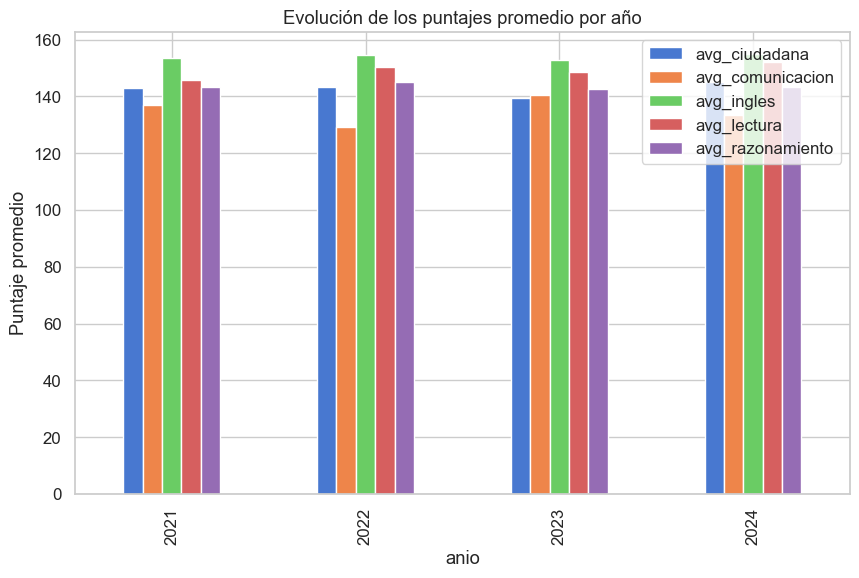

In [ ]:
df_year.set_index("anio").plot(kind="bar", figsize=(10,6))
plt.title("Evolución de los puntajes promedio por año")
plt.ylabel("Puntaje promedio")
plt.show()

En todos los años, Inglés es el módulo con mejor promedio y se mantiene estable alrededor de 154–155 puntos. Lectura Crítica muestra la mejor mejora en el tiempo pues pasa de 145.7 puntos en 2021 a 152.2 puntos en 2024, un salto claro de unos +6.5 puntos. Competencias Ciudadanas cae en 2023, pero se recupera en 2024 y termina un poco arriba de donde empezó (de 143.1 a 145.2). Razonamiento Cuantitativo se mantiene prácticamente casi igual pues sube en 2022, baja en 2023 y cierra 2024 casi igual que 2021 alrededor de 143.

El caso distinto es Comunicación Escrita es el promedio más bajo en todos los años y además es el más inestable. Baja fuerte en 2022 aproximadamente 129, aumenta en 2023 a 140 y vuelve a caer en 2024 aproximadamente a 134, quedando por debajo de 2021. En conclusión podemos decir que el módulo de Inglés lidera y se mantiene, Lectura Crítica mejora de forma sostenida, Competencias Ciudadanas se recupera, Razonamiento Cuantititivo está estable, y Comunicación Escrita necesita atención porque no consolida mejoras y termina con un nivel inferior al del inicio del periodo.

Distribución de puntajes por módulo 📉📈

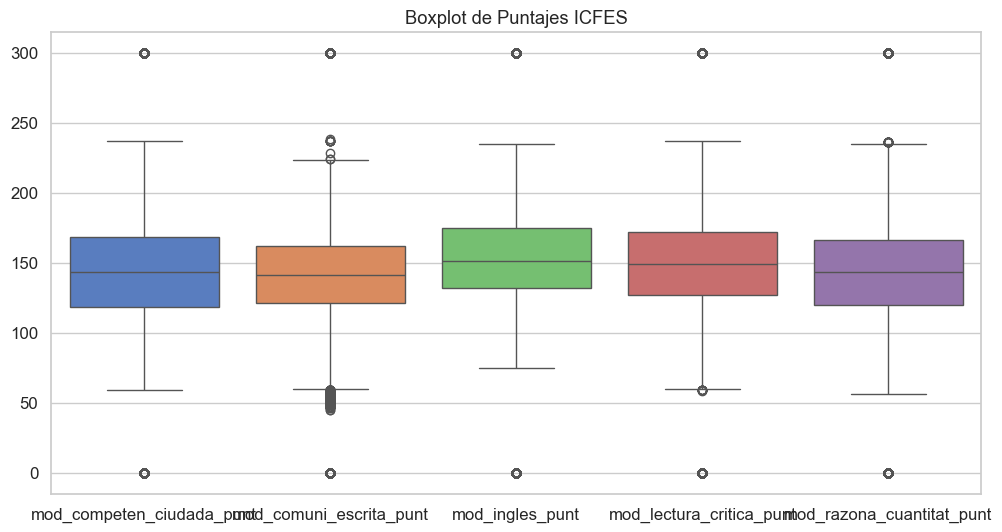

In [ ]:
# Boxplots
plt.figure(figsize=(12,6))
sns.boxplot(data=fact[[
    "mod_competen_ciudada_punt","mod_comuni_escrita_punt",
    "mod_ingles_punt","mod_lectura_critica_punt",
    "mod_razona_cuantitat_punt"
]])
plt.title("Boxplot de Puntajes ICFES")
plt.show()


En este gráfico vemos cómo se reparten los puntajes por módulo. La mayoría de resultados está entre 120 y 170 puntos. Los modulos de Inglés y Lectura suelen quedar un poco más altos; Ciudadanas y Cuantitativo se mantienen en la mitad; y Comunicación Escrita aparece más baja y con más diferencia entre estudiantes. En todos los módulos aparecen puntos extremos cerca de 0 y 300, que son valores poco comunes.

## Análisis Bivariado

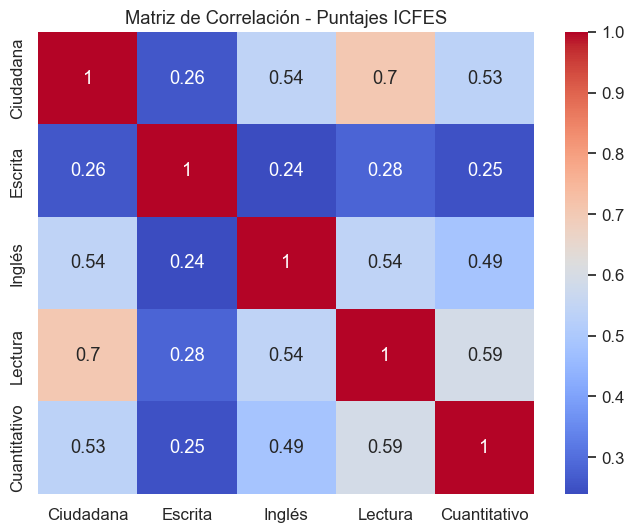

In [ ]:
# Correlaciones
cor = fact[[
    "mod_competen_ciudada_punt", "mod_comuni_escrita_punt",
    "mod_ingles_punt", "mod_lectura_critica_punt",
    "mod_razona_cuantitat_punt"
]].rename(columns={
    "mod_competen_ciudada_punt": "Ciudadana",
    "mod_comuni_escrita_punt": "Escrita",
    "mod_ingles_punt": "Inglés",
    "mod_lectura_critica_punt": "Lectura",
    "mod_razona_cuantitat_punt": "Cuantitativo"
}).corr()
plt.figure(figsize=(8,6))
sns.heatmap(cor, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación - Puntajes ICFES")
plt.show()

Cuando a un estudiante le va bien en un módulo, suele irle bien en otros. Las relaciones más claras se dan entre Ciudadana y Lectura (r=0.70, ~49% compartido), Lectura y Cuantitativo (r=0.59) y Inglés con Lectura/Ciudadana (r≈0.54). En cambio, Comunicación escrita se comporta más “por su cuenta”: sus vínculos con los demás son bajos (r=0.24–0.28). Lectura actúa como un pivote del desempeño, porque conecta de forma moderada-alta con varias áreas y parece resumir habilidades comunes. Así, mientras Lectura, Ciudadana, Inglés y Cuantitativo comparten un patrón general, Escrita capta algo más específico y puede requerir estrategias de preparación distintas.


In [ ]:
def comparar_puntajes(df_fact, df_dim, join_key, cat_var, puntajes):
    """
    Hace comparaciones de puntajes por variable categórica.
    - df_fact: tabla fact
    - df_dim: dimensión a unir
    - join_key: llave primaria para merge
    - cat_var: variable categórica
    - puntajes: lista de puntajes numéricos
    """
    df = df_fact.merge(df_dim[[join_key, cat_var]], on=join_key)

    # Estadísticos descriptivos
    tabla = df.groupby(cat_var)[puntajes].agg(["mean", "std", "count"])
    print(f"\n--- {cat_var} ---")
    print(tabla)

    # Gráficos
    for puntaje in puntajes:
        plt.figure(figsize=(8,5))
        sns.boxplot(data=df, x=cat_var, y=puntaje)
        plt.title(f"{puntaje} según {cat_var}")
        plt.xticks(rotation=45)
        plt.show()

    # ANOVA o Kruskal (según normalidad)
    grupos = [vals.dropna().values for _, vals in df.groupby(cat_var)[puntajes[0]]]
    if all(len(g) > 1 for g in grupos):  # evitar errores con grupos vacíos
        stat, p = stats.f_oneway(*grupos)
        print(f"ANOVA para {puntajes[0]} ~ {cat_var}: F={stat:.3f}, p={p:.3g}")

In [ ]:
def analizar_categoricas(df1, df2, join_key, var1, var2):
    """
    Tablas de contingencia y chi-cuadrado entre dos categóricas.
    """
    df = df1.merge(df2, on=join_key)
    tabla = pd.crosstab(df[var1], df[var2], margins=True, normalize="index")
    print(f"\n--- {var1} vs {var2} ---")
    print(tabla)

    # Heatmap
    plt.figure(figsize=(6,4))
    sns.heatmap(pd.crosstab(df[var1], df[var2], normalize="index"), annot=True, cmap="Blues")
    plt.title(f"{var1} vs {var2}")
    plt.show()

    # Chi-cuadrado
    chi2, p, dof, expected = stats.chi2_contingency(pd.crosstab(df[var1], df[var2]))
    print(f"Chi2={chi2:.3f}, p={p:.3g}, dof={dof}")

In [ ]:
dim_familia = pd.read_sql("SELECT * FROM dim_familia", conn)
dim_programa = pd.read_sql("SELECT * FROM dim_programa", conn)
dim_institucion = pd.read_sql("SELECT * FROM dim_institucion", conn)
dim_tiempo = pd.read_sql("SELECT * FROM dim_tiempo", conn)


--- estu_genero ---
            mod_competen_ciudada_punt                     \
                                 mean        std   count   
estu_genero                                                
F                          141.294373  32.887742  588790   
M                          144.976900  36.171692  426486   

            mod_comuni_escrita_punt                    mod_ingles_punt  \
                               mean        std   count            mean   
estu_genero                                                              
F                        135.954522  43.316703  588790      151.658220   
M                        134.096369  46.273563  426486      157.338821   

                               mod_lectura_critica_punt                     \
                   std   count                     mean        std   count   
estu_genero                                                                  
F            33.538670  588507               148.797366  30.221732  58879

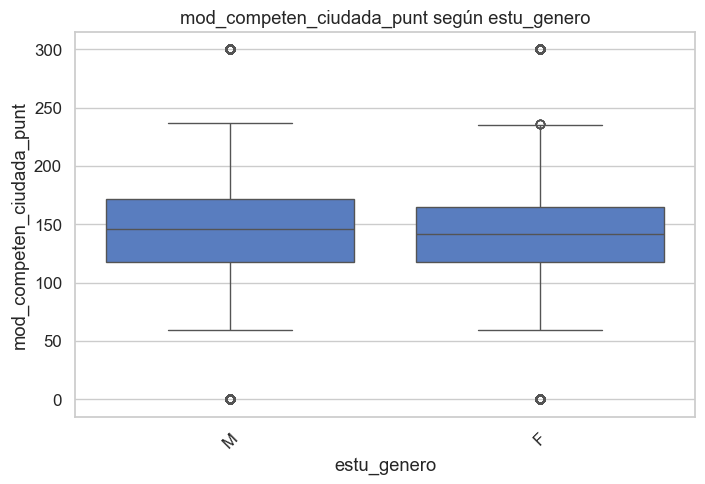

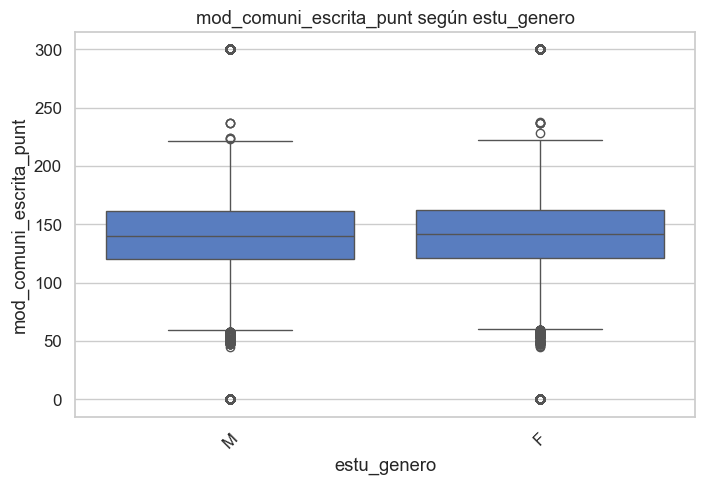

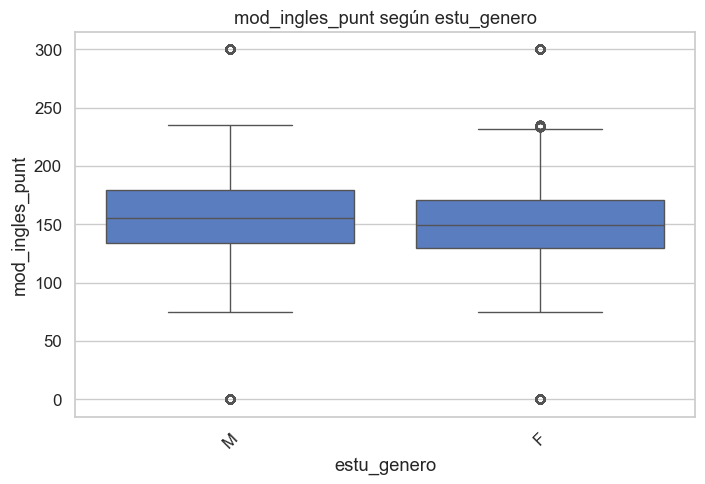

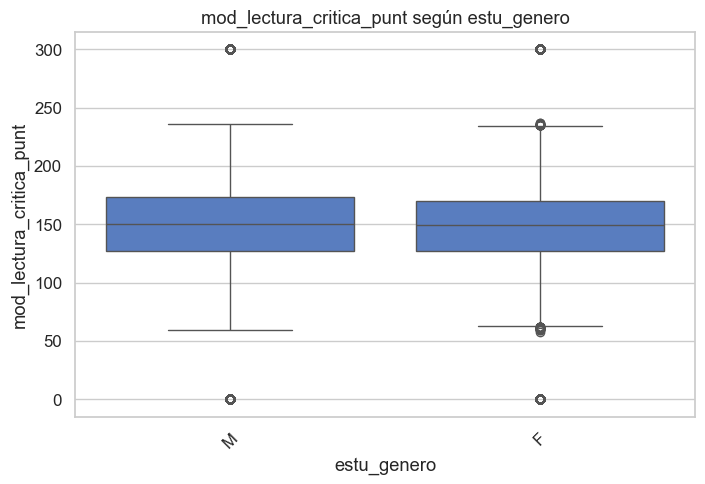

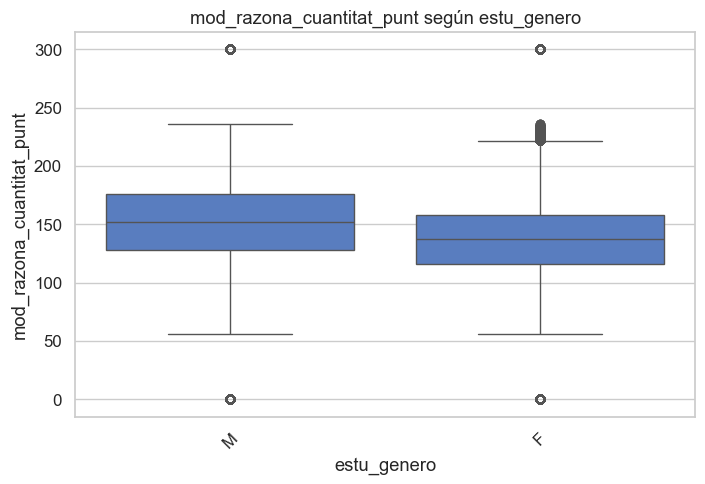

ANOVA para mod_competen_ciudada_punt ~ estu_genero: F=2849.996, p=0

--- estu_etnia ---
                 mod_competen_ciudada_punt                    \
                                      mean        std  count   
estu_etnia                                                     
Achagua                         133.400000  41.131496      5   
Afrodescendiente                128.254614  33.316812  22430   
Ambalo                          129.807692  28.964833     26   
Amorúa                          127.200000  27.470388     10   
Andoque                         158.500000  13.435029      2   
...                                    ...        ...    ...   
Yucuna                          111.625000  23.718212      8   
Yuko (Yukpa)                    130.166667  33.555472     12   
Yuri                            201.000000        NaN      1   
Yuruti (Tapuya)                 127.750000  37.624239      4   
Zenu (Senu)                     133.652619  32.560125   3322   

               

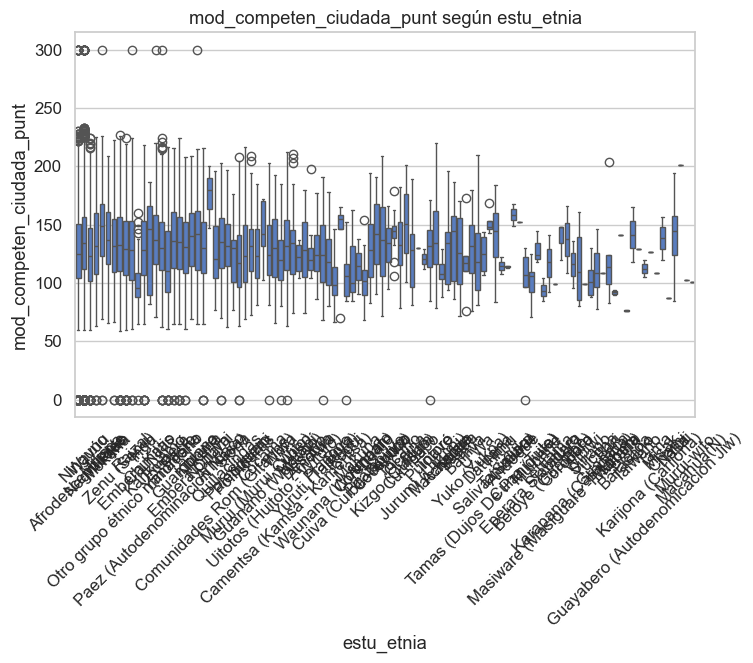

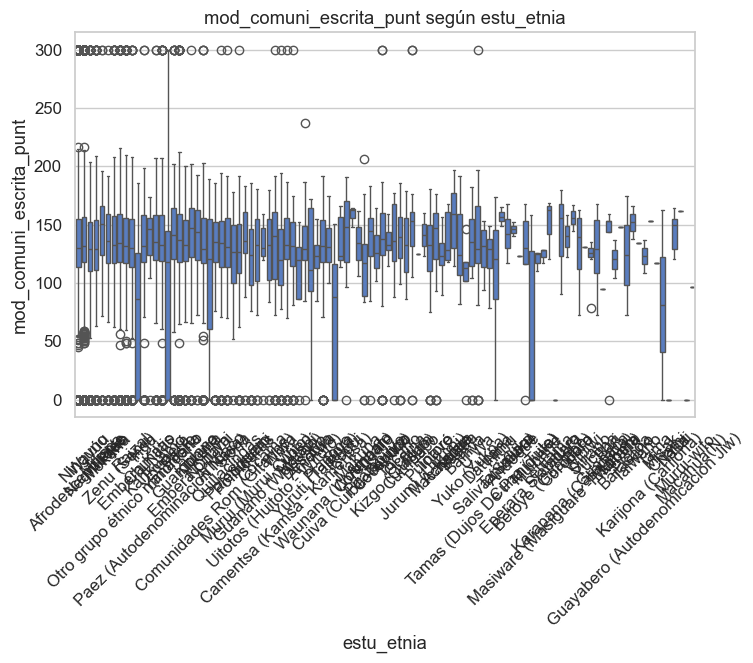

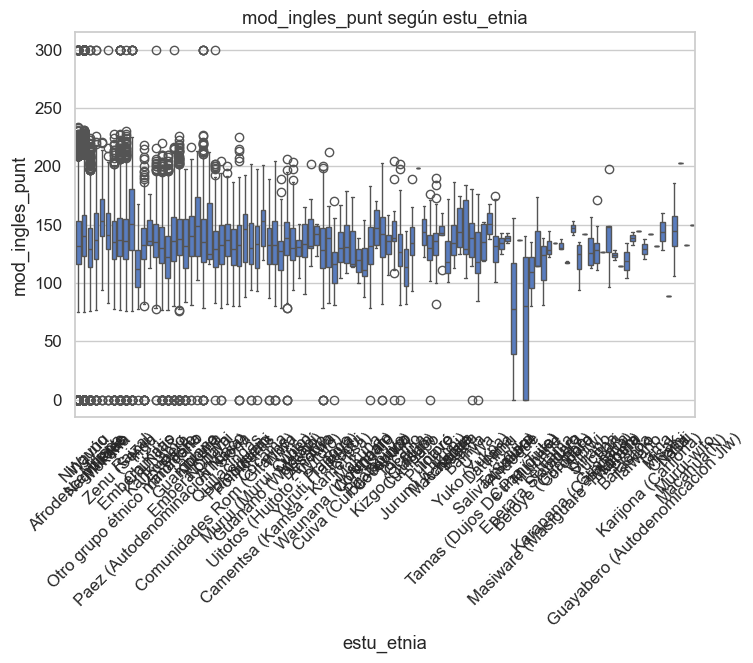

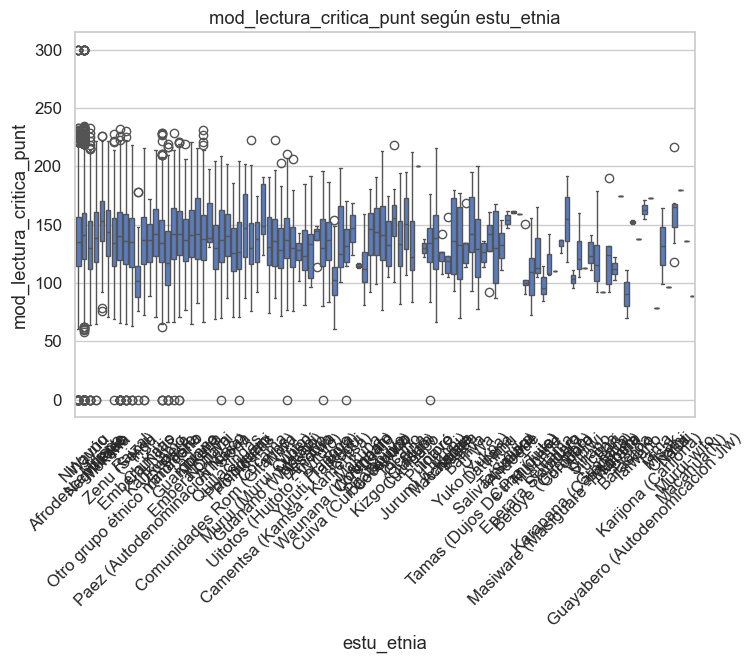

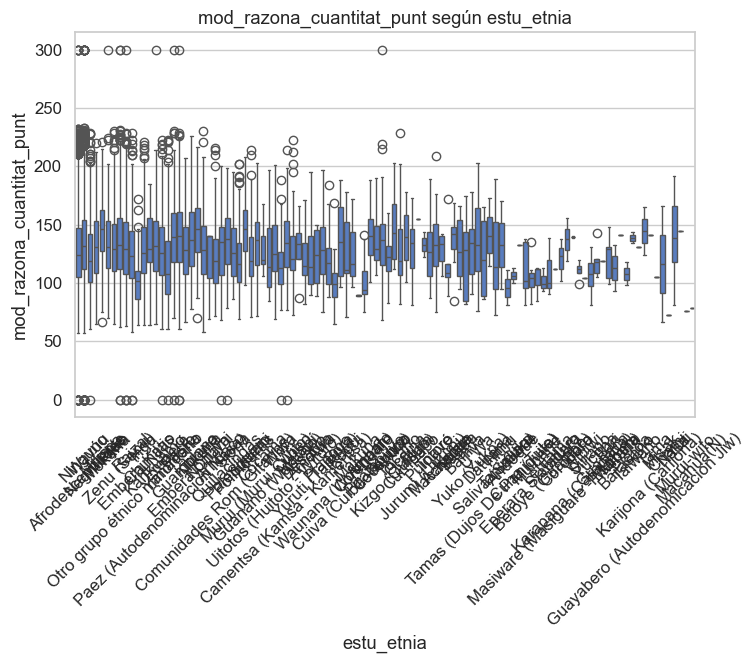

In [ ]:

puntajes = [
    "mod_competen_ciudada_punt", "mod_comuni_escrita_punt",
    "mod_ingles_punt", "mod_lectura_critica_punt",
    "mod_razona_cuantitat_punt"]

## a) dim_estudiante
comparar_puntajes(fact, dim_estudiante, "id_estudiante", "estu_genero", puntajes)
comparar_puntajes(fact, dim_estudiante, "id_estudiante", "estu_etnia", puntajes)


**Género vs puntajes**
Las diferencias por género son en general **pequeñas**: en **Ciudadana**, **Escrita** y **Lectura** las medianas son casi idénticas y el solapamiento es alto; en **Inglés** aparece una **ventaja modesta** para hombres (5–6 puntos) y en **Razonamiento cuantitativo** la brecha es la **más visible** (14–15 puntos a favor de hombres). En todos los módulos la **variación dentro de cada género** es mucho mayor que la diferencia entre ellos, por lo que no se observan brechas estructurales salvo una ventaja consistente en Cuantitativo.

**Etnia vs puntajes**
Se detecta **heterogeneidad** entre etnias, pero con **fuerte solapamiento**: la mayoría de medianas se ubican en **130–155** y la dispersión interna es amplia. Muchas categorías tienen **n muy pequeño**, lo que explica valores extremos poco estables; en general las **diferencias son modestas** y solo en **Cuantitativo** la separación entre grupos resulta algo más visible.


--- fami_estratovivienda ---
                     mod_competen_ciudada_punt                     \
                                          mean        std   count   
fami_estratovivienda                                                
Estrato 1                           134.516968  31.179229  203556   
Estrato 2                           141.064022  32.060003  349175   
Estrato 3                           146.642427  33.213018  289096   
Estrato 4                           155.359070  35.310906   85986   
Estrato 5                           159.309667  36.483310   29845   
Estrato 6                           161.028962  38.086038   16366   
Sin Estrato                         130.836673  36.388248    4990   

                     mod_comuni_escrita_punt                     \
                                        mean        std   count   
fami_estratovivienda                                              
Estrato 1                         129.214074  45.549026  203556   
Estrato 2  

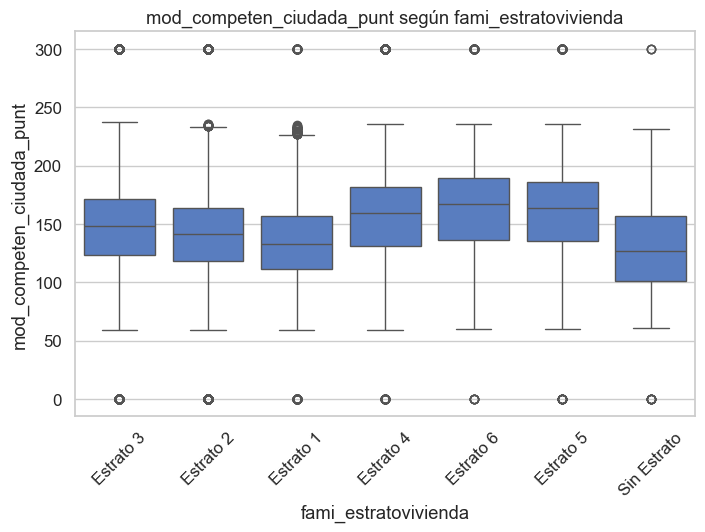

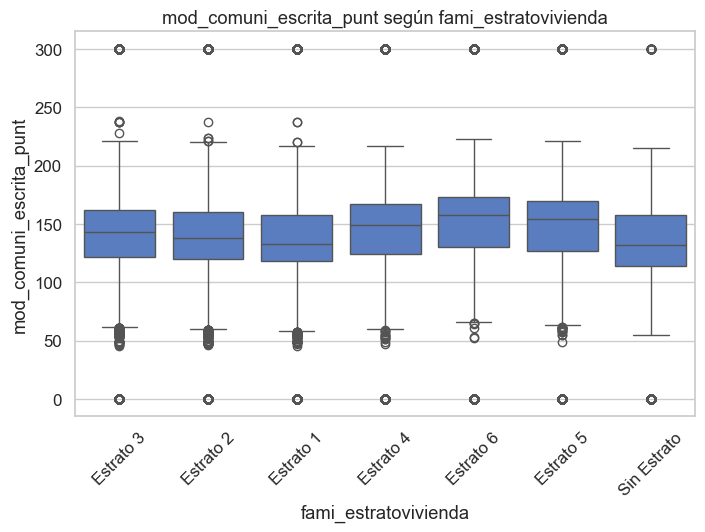

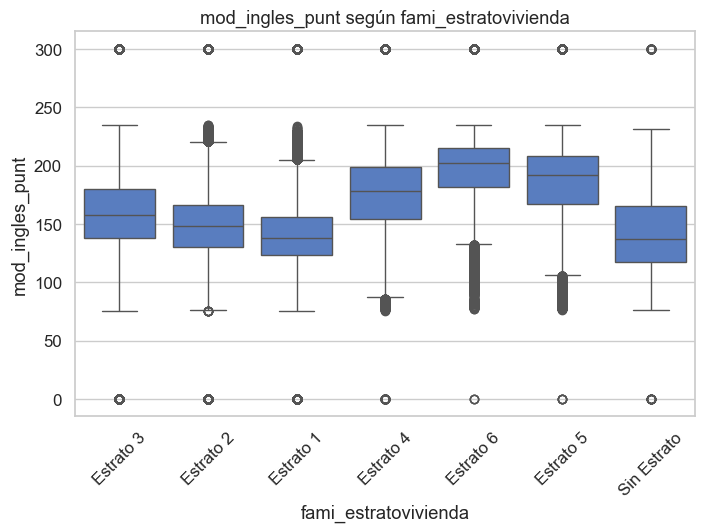

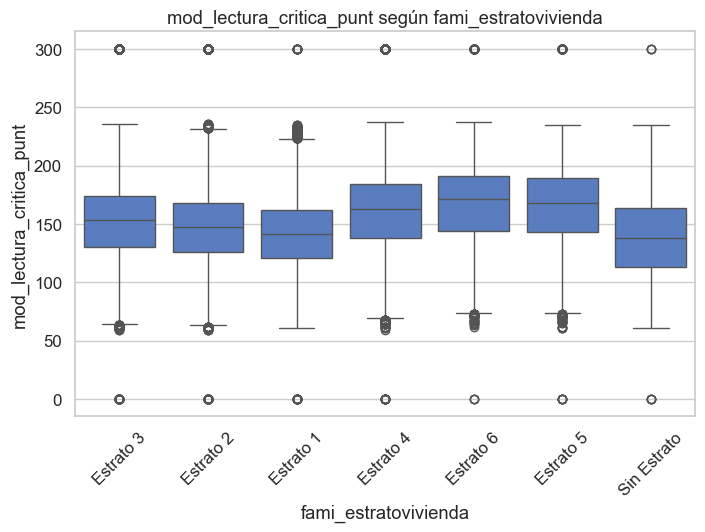

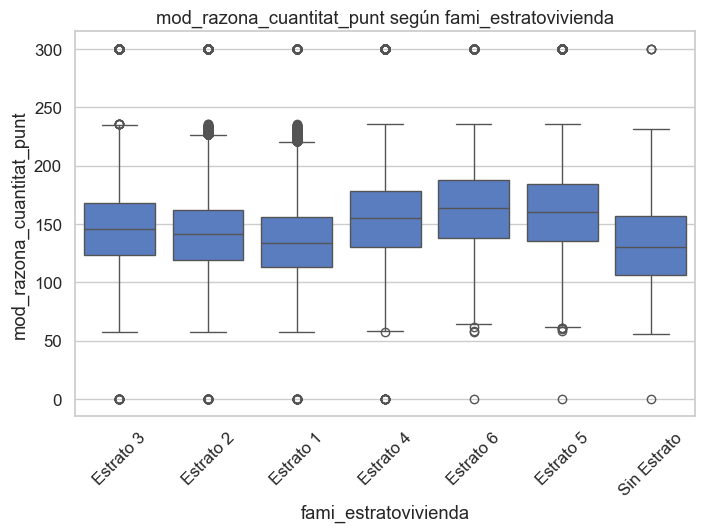

ANOVA para mod_competen_ciudada_punt ~ fami_estratovivienda: F=7241.464, p=0

--- fami_educacionmadre ---
                                     mod_competen_ciudada_punt             \
                                                          mean        std   
fami_educacionmadre                                                         
Educación profesional completa                      152.231962  34.975740   
Educación profesional incompleta                    150.152559  35.182539   
Ninguno                                             127.068007  29.627643   
No Aplica                                           134.383040  34.431867   
No sabe                                             141.622870  35.778942   
Postgrado                                           160.267301  35.714680   
Primaria completa                                   136.525293  30.703249   
Primaria incompleta                                 134.325563  30.009308   
Secundaria (Bachillerato) completa             

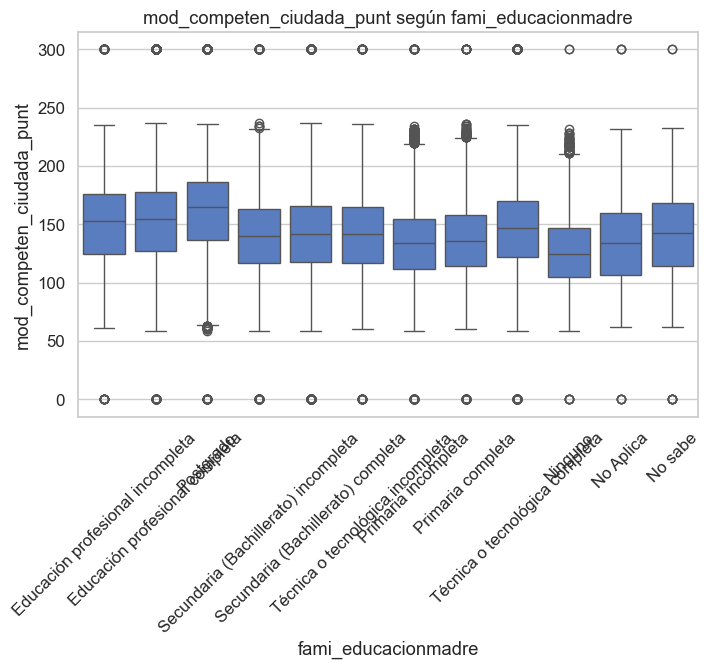

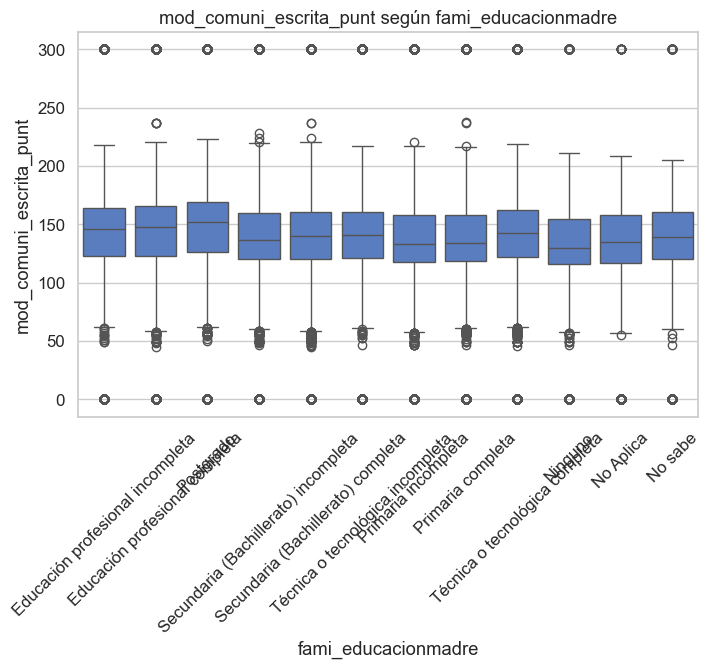

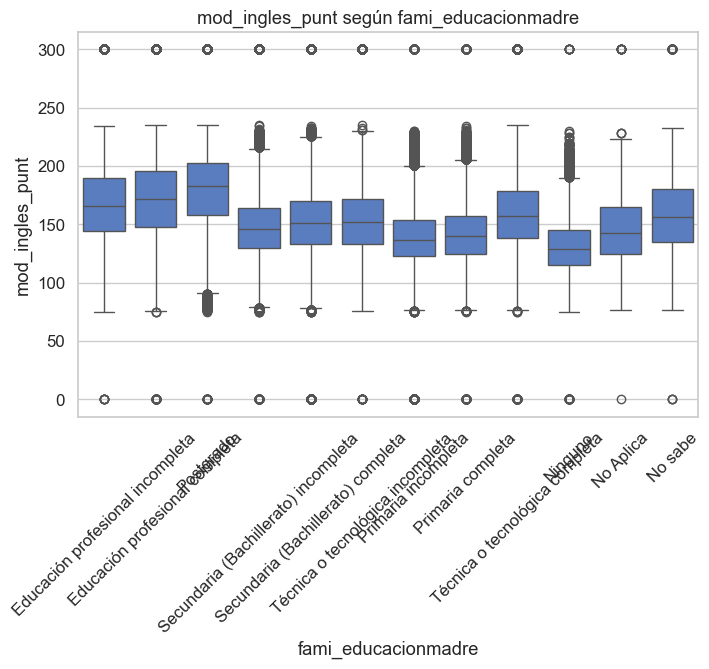

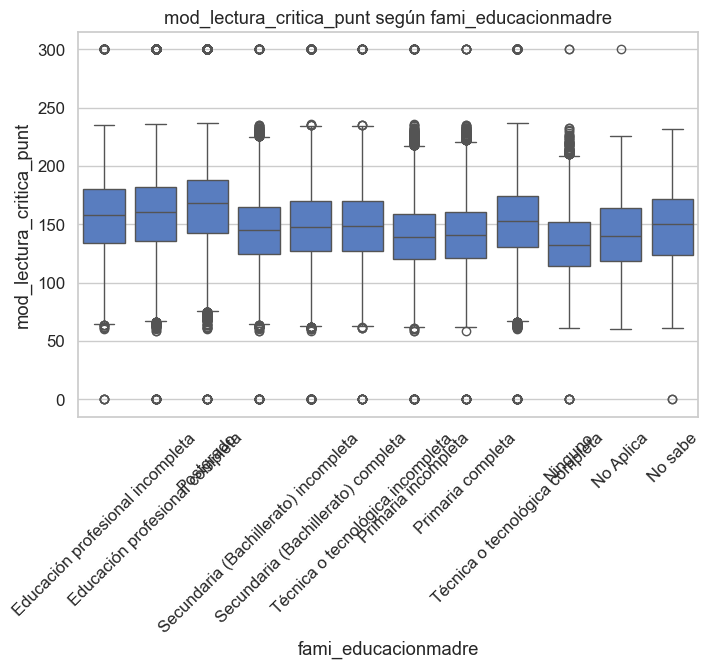

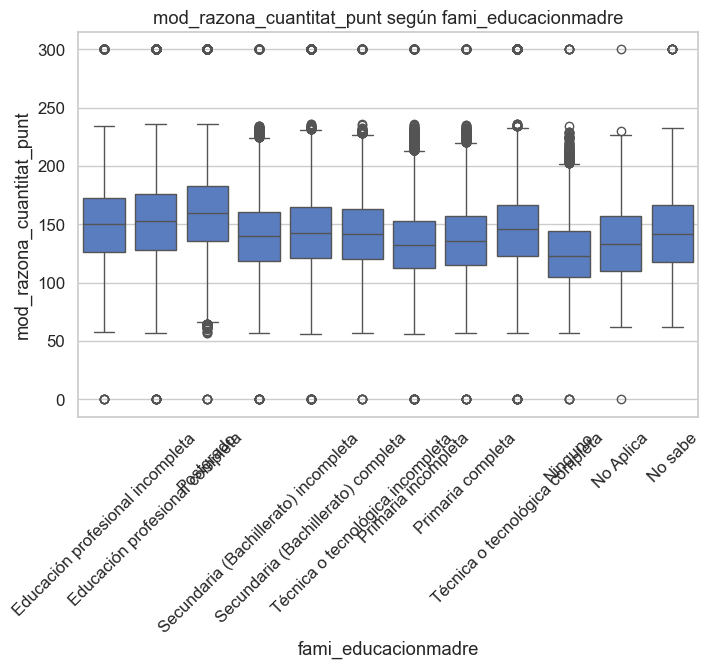

ANOVA para mod_competen_ciudada_punt ~ fami_educacionmadre: F=4800.775, p=0

--- fami_educacionpadre ---
                                     mod_competen_ciudada_punt             \
                                                          mean        std   
fami_educacionpadre                                                         
Educación profesional completa                      151.773423  35.049833   
Educación profesional incompleta                    149.540728  34.606797   
Ninguno                                             129.502170  30.634694   
No Aplica                                           143.993725  33.007579   
No sabe                                             148.523082  33.332180   
Postgrado                                           161.386985  35.858496   
Primaria completa                                   137.061637  31.060300   
Primaria incompleta                                 135.804939  30.565126   
Secundaria (Bachillerato) completa              

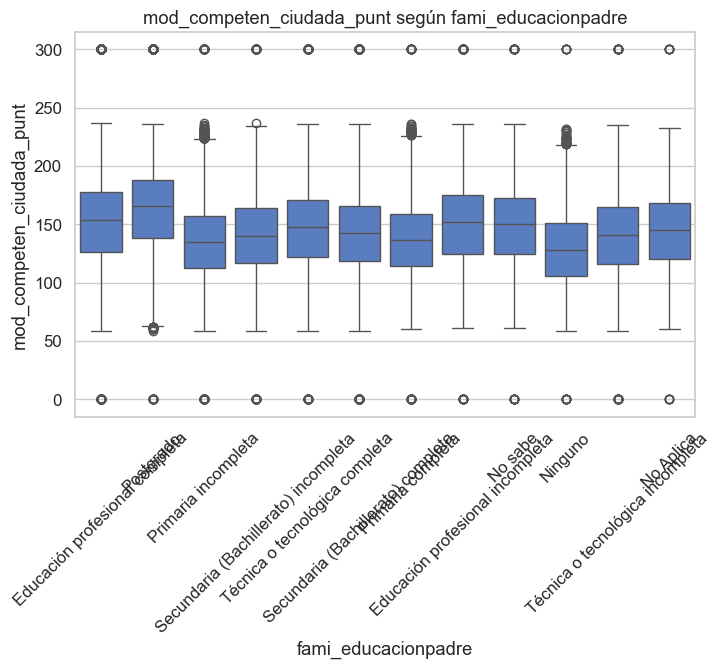

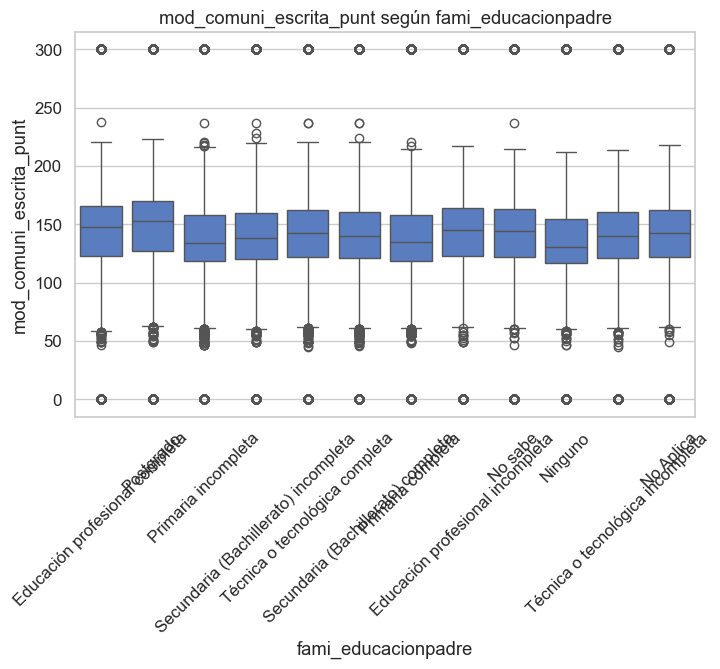

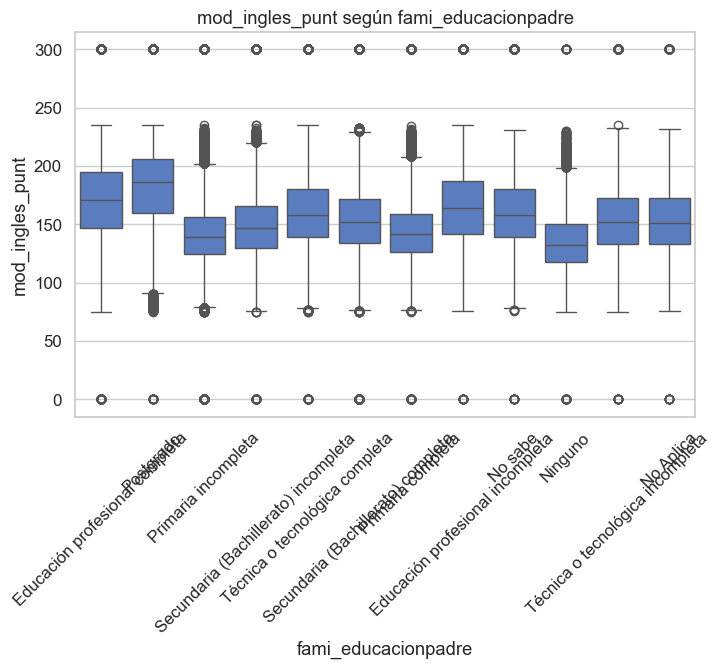

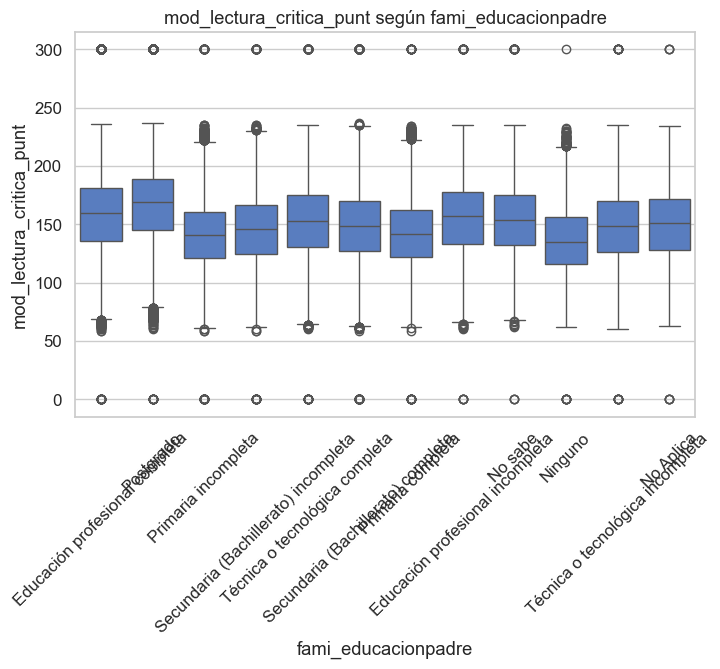

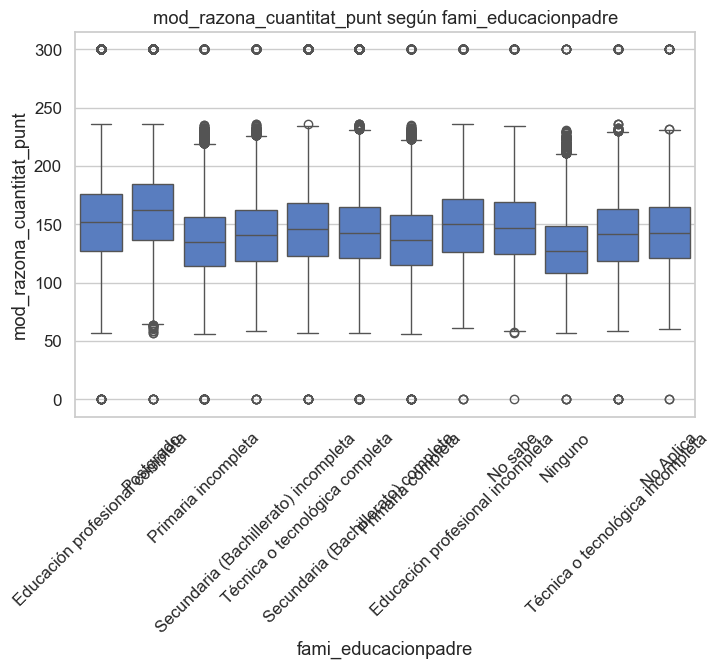

ANOVA para mod_competen_ciudada_punt ~ fami_educacionpadre: F=4583.625, p=0

--- fami_tieneinternet ---
                   mod_competen_ciudada_punt                     \
                                        mean        std   count   
fami_tieneinternet                                                
No                                132.123789  31.066667  106746   
Si                                144.762756  33.544067  877724   

                   mod_comuni_escrita_punt                    mod_ingles_punt  \
                                      mean        std   count            mean   
fami_tieneinternet                                                              
No                              128.133148  47.291492  106746      137.914423   
Si                              136.128170  43.862717  877724      157.129510   

                                      mod_lectura_critica_punt             \
                          std   count                     mean        std   


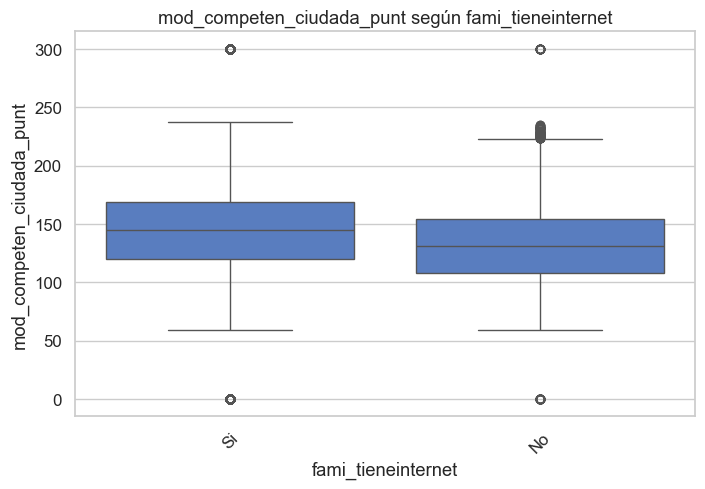

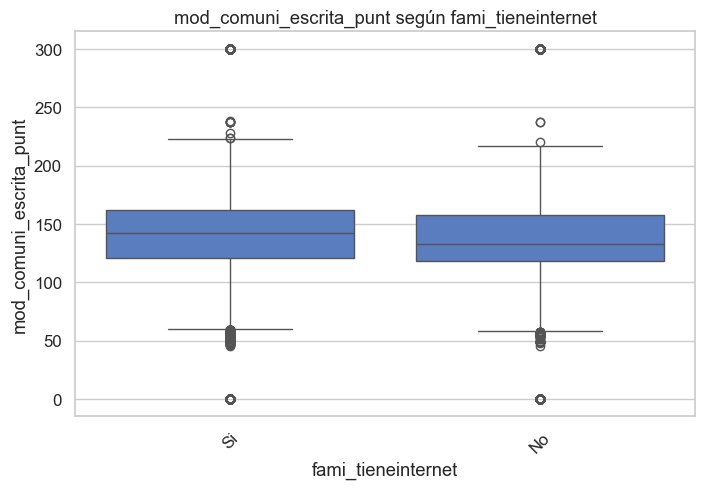

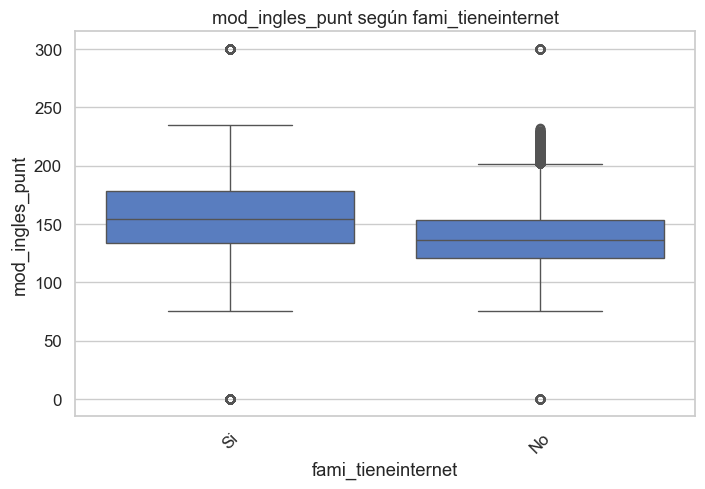

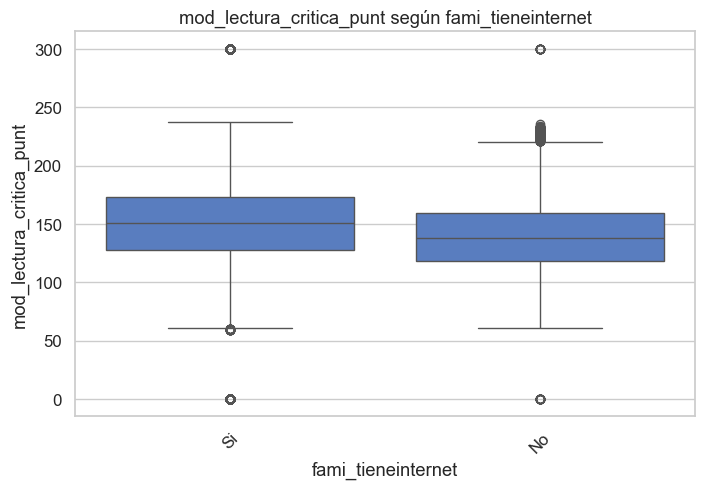

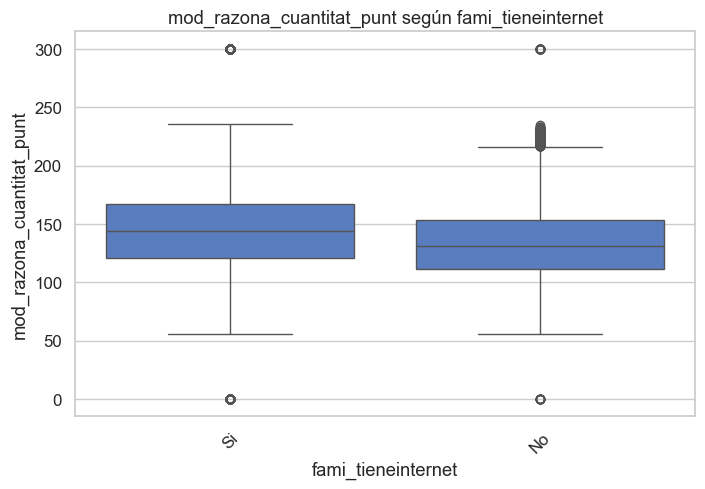

ANOVA para mod_competen_ciudada_punt ~ fami_tieneinternet: F=13723.024, p=0

--- fami_tienecomputador ---
                     mod_competen_ciudada_punt                     \
                                          mean        std   count   
fami_tienecomputador                                                
No                                  132.081139  30.964299  113226   
Si                                  145.012061  33.541927  856724   

                     mod_comuni_escrita_punt                     \
                                        mean        std   count   
fami_tienecomputador                                              
No                                128.288847  47.006405  113226   
Si                                136.257889  43.857307  856724   

                     mod_ingles_punt                     \
                                mean        std   count   
fami_tienecomputador                                      
No                        139.17262

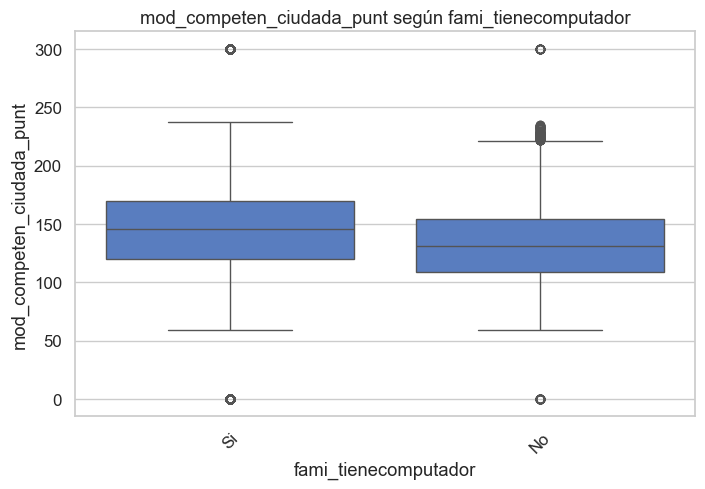

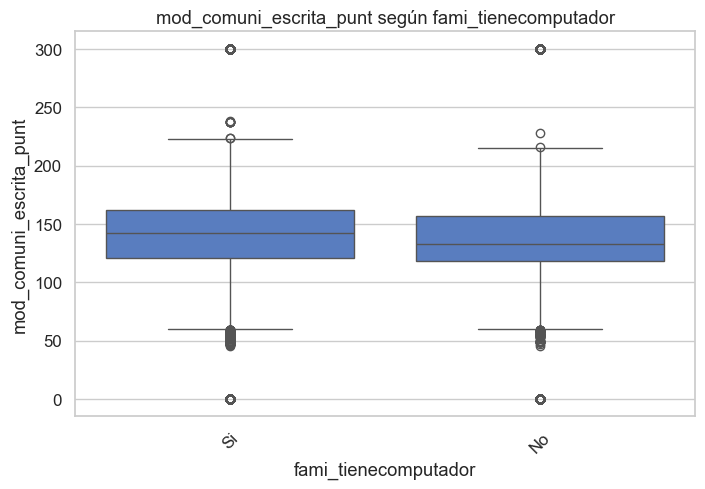

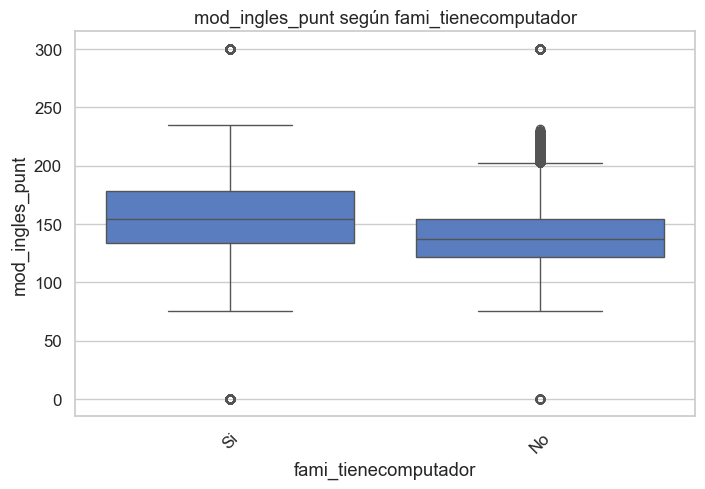

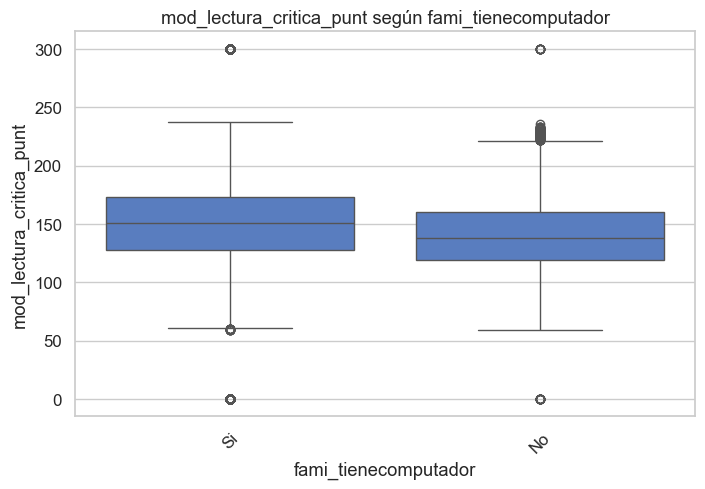

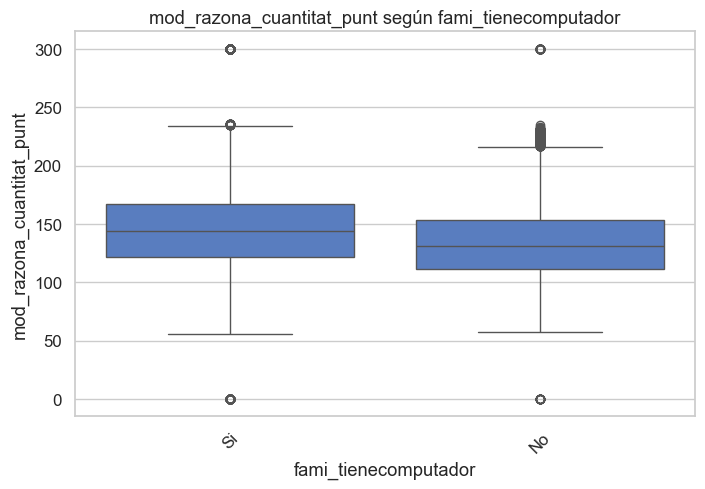

ANOVA para mod_competen_ciudada_punt ~ fami_tienecomputador: F=15124.415, p=0


In [ ]:

## b) dim_familia
comparar_puntajes(fact, dim_familia, "id_familia", "fami_estratovivienda", puntajes)
comparar_puntajes(fact, dim_familia, "id_familia", "fami_educacionmadre", puntajes)
comparar_puntajes(fact, dim_familia, "id_familia", "fami_educacionpadre", puntajes)
comparar_puntajes(fact, dim_familia, "id_familia", "fami_tieneinternet", puntajes)
comparar_puntajes(fact, dim_familia, "id_familia", "fami_tienecomputador", puntajes)


**Estrato socioeconómico del hogar vs puntajes**
Se observa un **gradiente ascendente** claro: los puntajes aumentan desde **E1/Sin estrato** hacia **E5–E6**. El efecto es **más fuerte en Inglés** (+50 puntos entre E1 y E6) y **moderado** en **Ciudadana**, **Escrita**, **Lectura** y **Cuantitativo** (+26–33 puntos). Aun así, las cajas se **solapan** ampliamente y la desviación estándar ronda **30–48** puntos, por lo que el estrato **no clasifica** con precisión a individuos; “**Sin estrato**” se comporta similar a **E1**.


**Educación de la madre vs puntajes**
Existe un **gradiente positivo**: a mayor nivel educativo materno, mejores puntajes en todos los módulos. Las categorías **profesional/postgrado** superan de forma consistente a **Ninguno/No aplica/No sabe**, con **efectos más marcados en Inglés y Lectura**. Sin embargo, la **variación intragrupo** es alta y genera solapamiento entre categorías, por lo que estos promedios describen **tendencias poblacionales** pero no permiten clasificar estudiantes de manera individual.


**Educación del padre vs puntajes**
Patrón **monotónico** similar: más educación paterna se asocia con puntajes más altos. **Inglés** muestra el **salto mayor** (+50 puntos entre extremos), **Lectura** y **Ciudadana** aumentan 30–32 puntos y **Cuantitativo** ~22 puntos. Aunque la señal es clara, la **dispersión** dentro de cada categoría sigue siendo grande, por lo que la educación del padre actúa como **correlato** del desempeño y no como criterio suficiente de clasificación individual.


**Acceso a internet del hogar vs puntajes**
Los estudiantes con internet en casa tienden a rendir mejor: las distribuciones se desplazan hacia puntajes más altos y se reduce la presencia de valores muy bajos. El efecto es más claro en Inglés y Razonamiento Cuantitativo, seguido de Lectura; en Ciudadana y Escritura la diferencia existe pero es más discreta. Aun así, dentro de cada grupo hay mucha variación: contar con internet ayuda (acceso a recursos, práctica y apoyo), pero no determina por sí solo el desempeño.

**Acceso a computador del hogar vs puntajes**
Disponer de computador en el hogar también se asocia con puntajes superiores de forma consistente en todos los módulos. La mejora vuelve a notarse con mayor fuerza en Inglés, Cuantitativo y Lectura, mientras que en Ciudadana y Escritura la brecha es moderada. Como en el caso de internet, las cajas entre grupos se solapan: el computador ofrece una ventaja de medios y práctica, pero las diferencias individuales y escolares siguen pesando mucho en el resultado final.



--- inst_caracter_academico ---
                          mod_competen_ciudada_punt                     \
                                               mean        std   count   
inst_caracter_academico                                                  
INSTITUCIÓN TECNOLÓGICA                  128.350018  29.607480   35941   
INSTITUCIÓN UNIVERSITARIA                134.902594  30.875884  346836   
TÉCNICA PROFESIONAL                      129.264244  29.830239   23221   
UNIVERSIDAD                              149.536574  35.249605  581819   

                          mod_comuni_escrita_punt                     \
                                             mean        std   count   
inst_caracter_academico                                                
INSTITUCIÓN TECNOLÓGICA                124.959239  43.971256   35941   
INSTITUCIÓN UNIVERSITARIA              130.513309  43.498251  346836   
TÉCNICA PROFESIONAL                    127.953878  42.401560   23221   
UNIVERSIDAD     

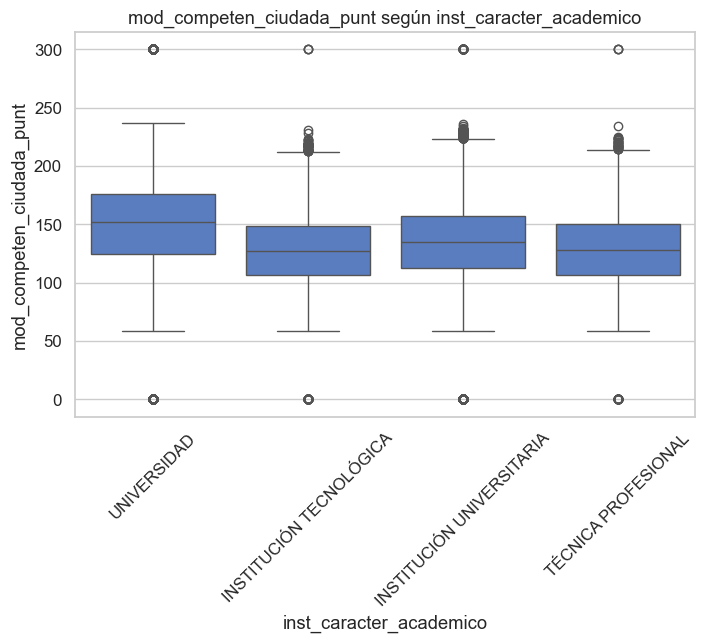

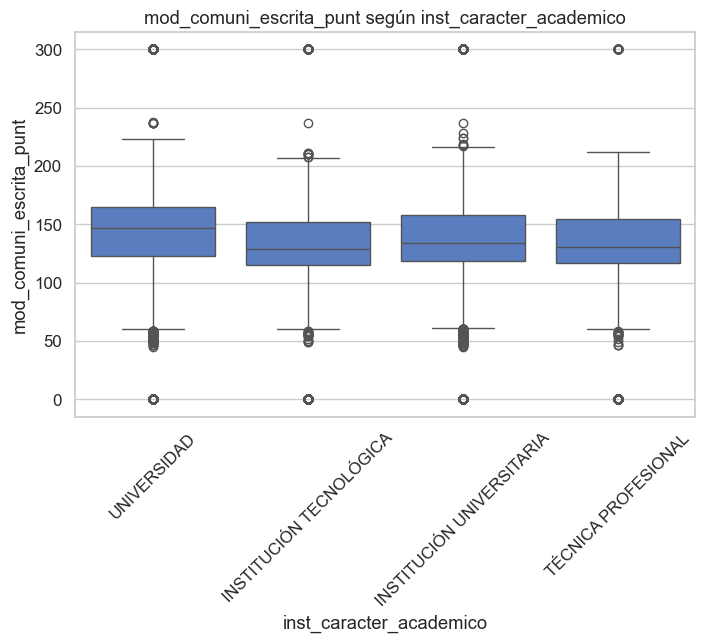

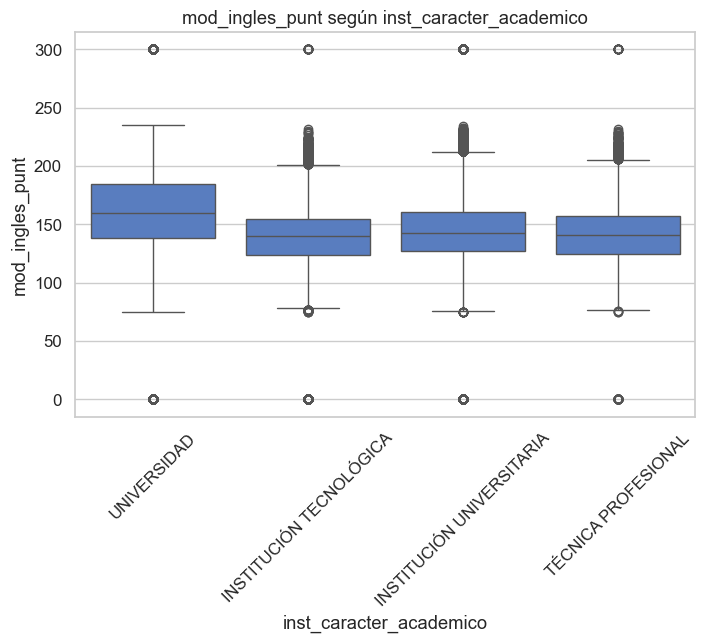

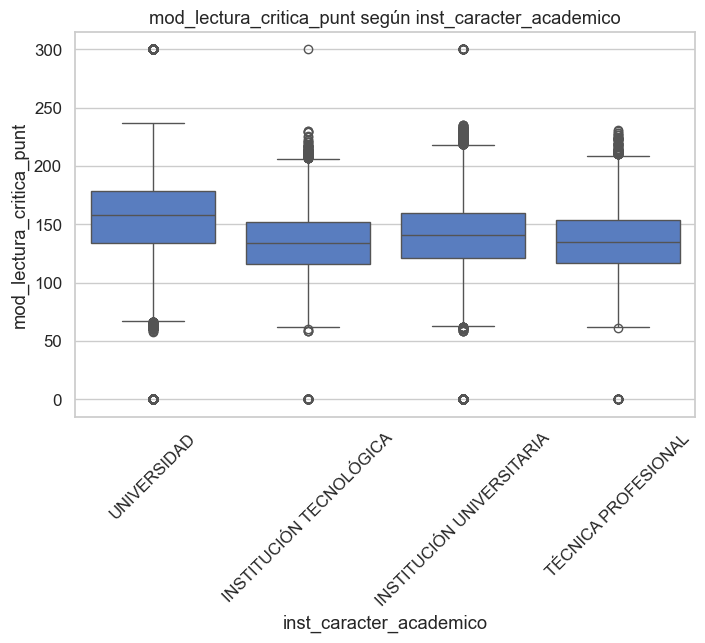

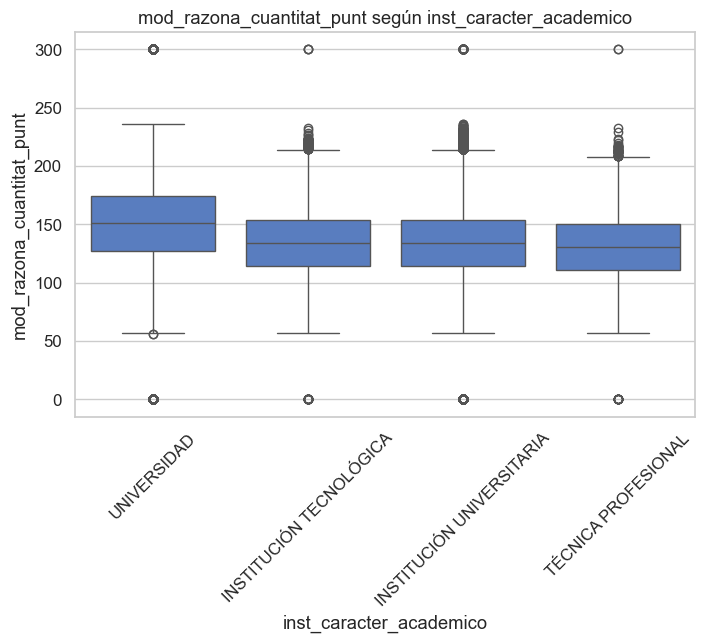

ANOVA para mod_competen_ciudada_punt ~ inst_caracter_academico: F=17769.594, p=0

--- inst_origen ---
                         mod_competen_ciudada_punt                     \
                                              mean        std   count   
inst_origen                                                             
NO OFICIAL - CORPORACIÓN                139.037018  33.256981  316847   
NO OFICIAL - FUNDACIÓN                  144.193720  34.606379  318806   
OFICIAL DEPARTAMENTAL                   145.760146  34.213251  154390   
OFICIAL MUNICIPAL                       148.548319  34.300033   24721   
OFICIAL NACIONAL                        145.738564  35.242072  172000   
REGIMEN ESPECIAL                        133.408357  31.058365    1053   

                         mod_comuni_escrita_punt                     \
                                            mean        std   count   
inst_origen                                                           
NO OFICIAL - CORPORACIÓN   

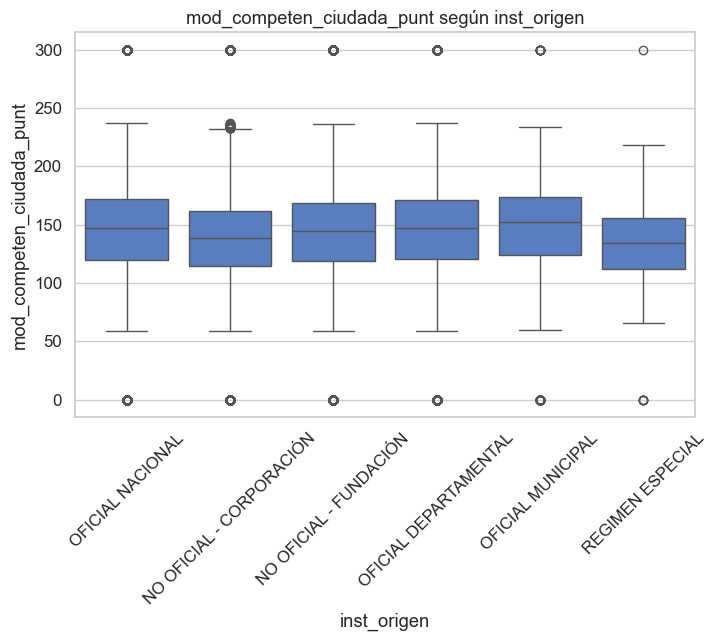

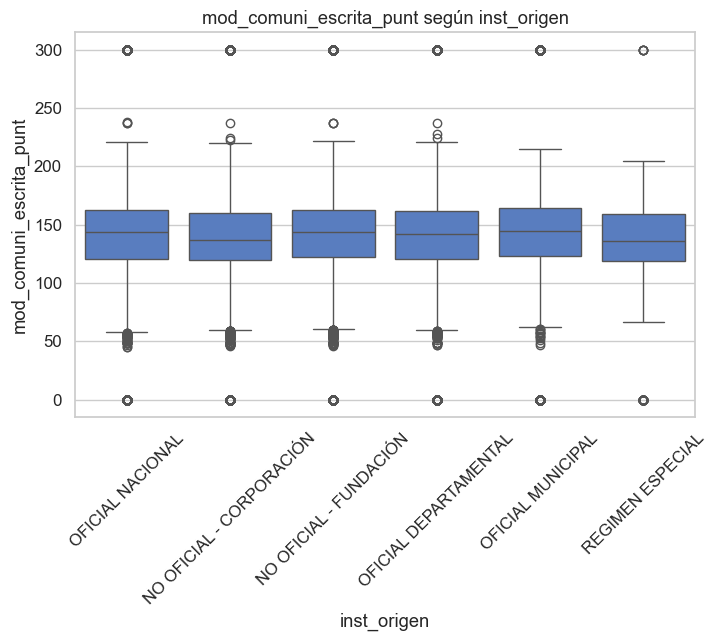

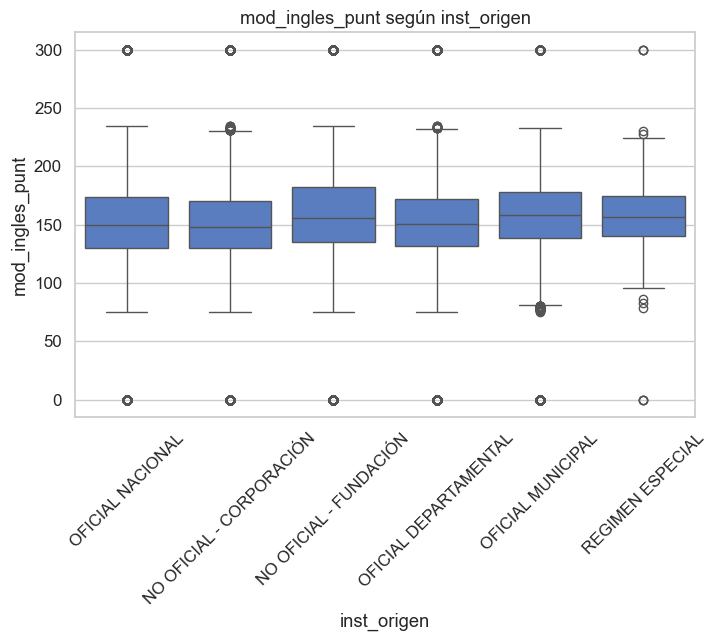

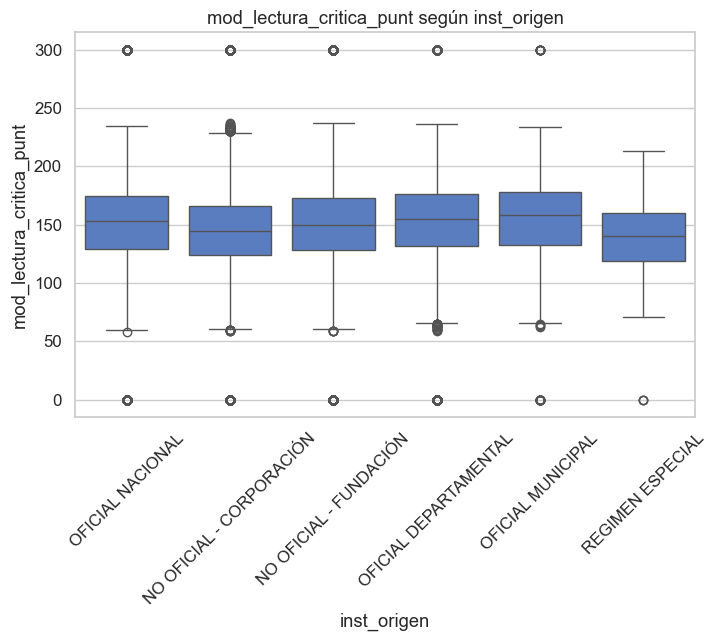

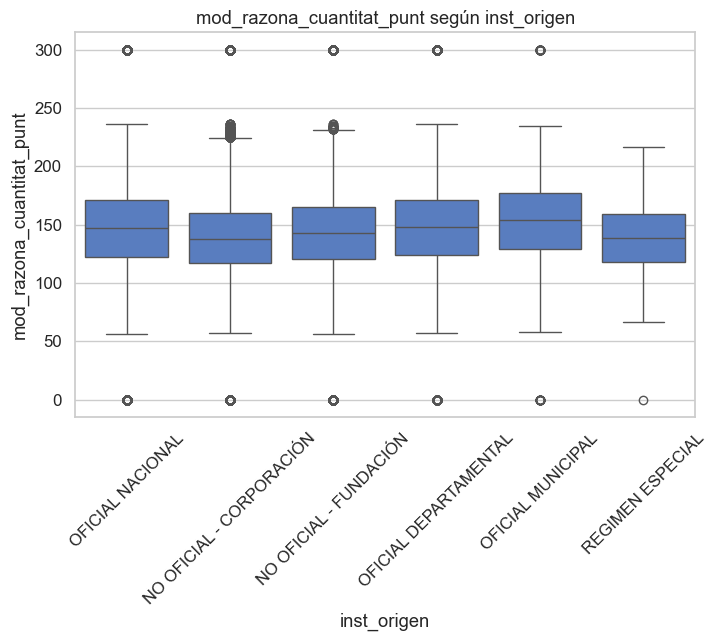

ANOVA para mod_competen_ciudada_punt ~ inst_origen: F=1491.427, p=0


In [ ]:

## c) dim_institucion
comparar_puntajes(fact, dim_institucion, "id_institucion", "inst_caracter_academico", puntajes)
comparar_puntajes(fact, dim_institucion, "id_institucion", "inst_origen", puntajes)


**Nivel del programa académico vs puntajes**
Los programas **universitarios** muestran sistemáticamente las medianas e IQR más altos en todas las áreas, seguidos por **tecnológicos** y, después, **técnico profesionales**. La brecha es especialmente clara en Inglés, Lectura y Cuantitativo, mientras que en Ciudadana la diferencia es algo más contenida, aunque consistente. Pese a ello, las cajas se solapan: el nivel del programa marca una tendencia de rendimiento, pero conviven estudiantes de alto y bajo desempeño en cada nivel (y el tamaño muestral de los técnico profesionales puede acotar su variabilidad observada).

**Origen institucional vs puntajes**
Se observa un patrón consistente por módulos: las instituciones oficiales municipales tienden a ubicarse en la parte alta de los puntajes, seguidas por las oficiales departamentales y luego las oficiales nacionales; las no oficiales (fundación) quedan en la zona intermedia, mientras que las no oficiales (corporación) y régimen especial aparecen en la parte baja. Aun con esa gradación, las distribuciones muestran alto solapamiento y gran variabilidad interna, por lo que las brechas son moderadas en términos prácticos. Además, los grupos difieren mucho en tamaño muestral (municipal y régimen especial son pequeños), lo que puede inflar o hacer inestables algunos promedios. Esta es una asociación descriptiva, no causal: el patrón podría reflejar diferencias de composición (programas ofrecidos, regiones, perfil socioeconómico, educación y recursos del hogar, etc.)


--- estu_nivel_prgm_academico ---
                          mod_competen_ciudada_punt                     \
                                               mean        std   count   
estu_nivel_prgm_academico                                                
TECNOLOGÍA                               104.750000  40.982720       4   
TÉCNICO PROFESIONAL                       87.500000  12.020815       2   
UNIVERSITARIO                            143.151295  34.347876  987809   

                          mod_comuni_escrita_punt                     \
                                             mean        std   count   
estu_nivel_prgm_academico                                              
TECNOLOGÍA                             138.500000  19.122413       4   
TÉCNICO PROFESIONAL                     56.000000  79.195959       2   
UNIVERSITARIO                          135.396896  44.477794  987809   

                          mod_ingles_punt                     \
                       

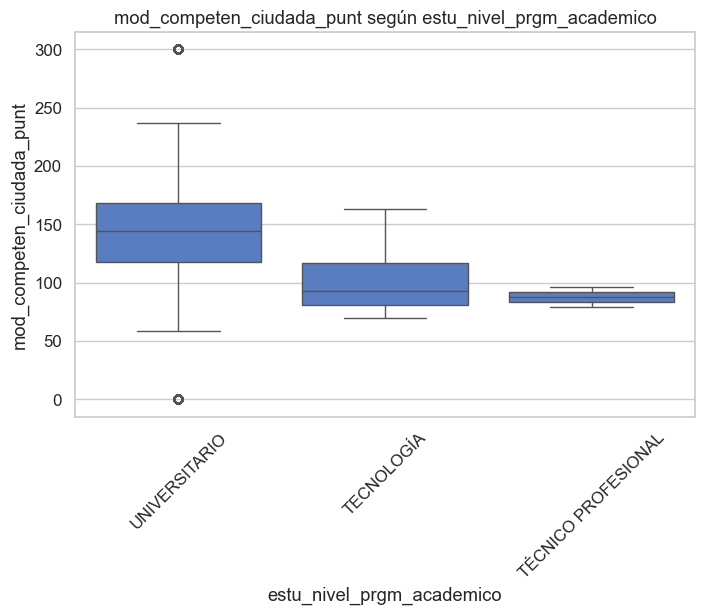

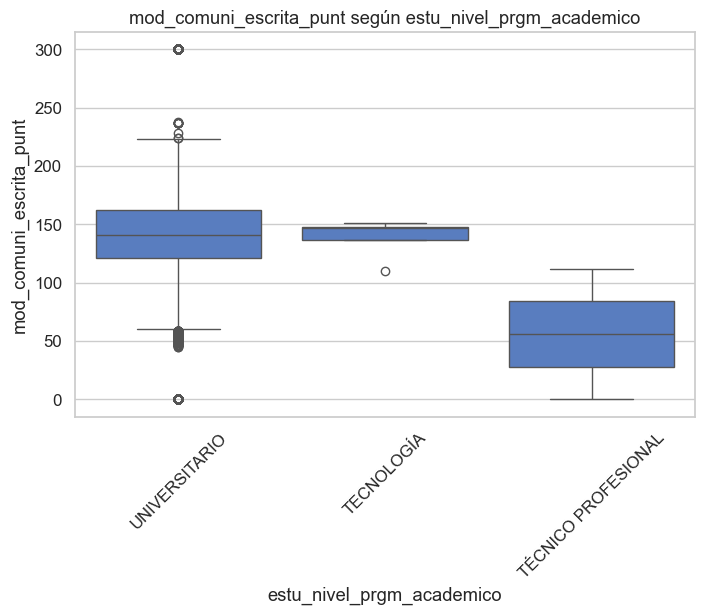

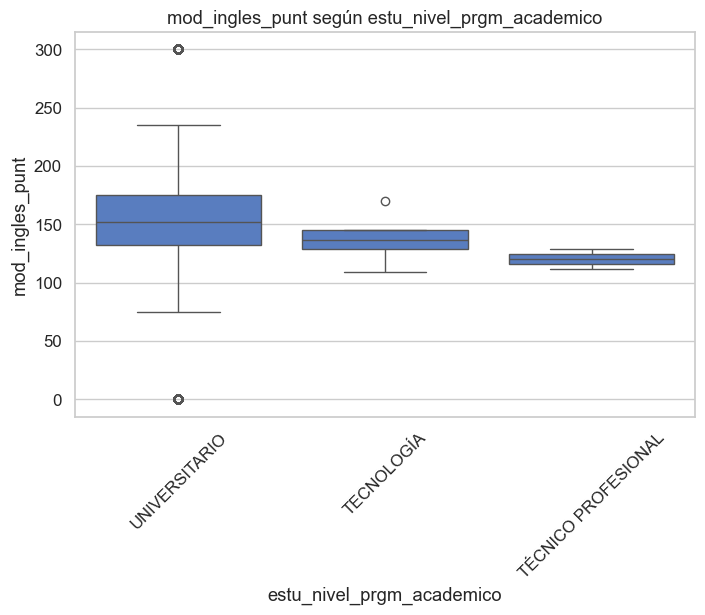

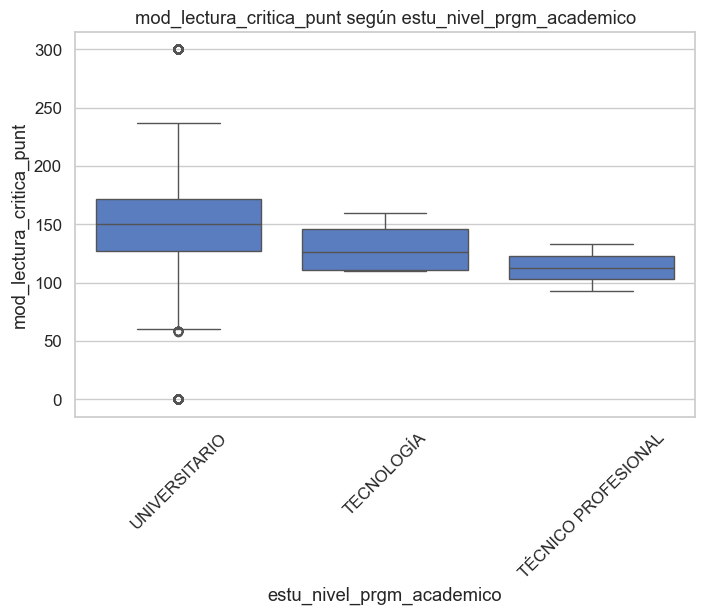

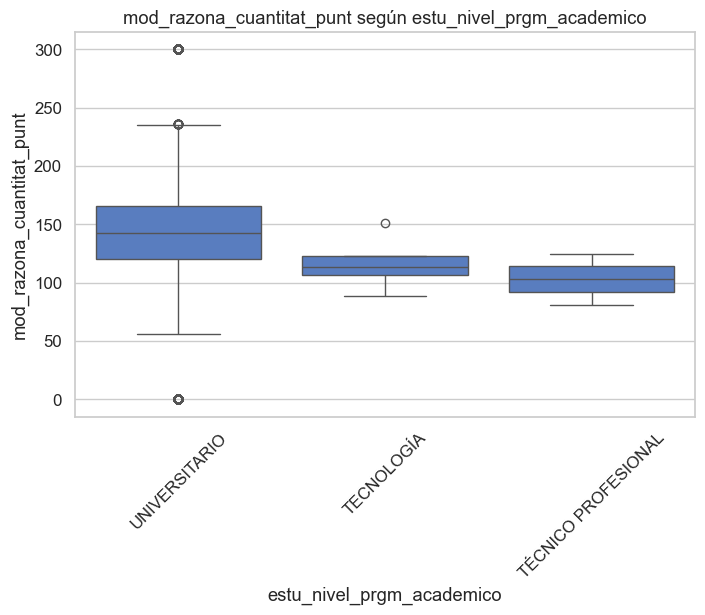

ANOVA para mod_competen_ciudada_punt ~ estu_nivel_prgm_academico: F=5.125, p=0.00595

--- estu_metodo_prgm ---
                 mod_competen_ciudada_punt                     \
                                      mean        std   count   
estu_metodo_prgm                                                
DISTANCIA                       129.966642  29.262082  131783   
DISTANCIA VITUAL                134.009674  30.493497   92311   
PRESENCIAL                      146.531213  34.847068  763699   
SEMI-PRESENCIAL                 133.250000  21.355717      16   

                 mod_comuni_escrita_punt                    mod_ingles_punt  \
                                    mean        std   count            mean   
estu_metodo_prgm                                                              
DISTANCIA                     126.483621  45.317145  131783      135.325723   
DISTANCIA VITUAL              130.954599  43.242772   92311      142.873638   
PRESENCIAL                    137.4716

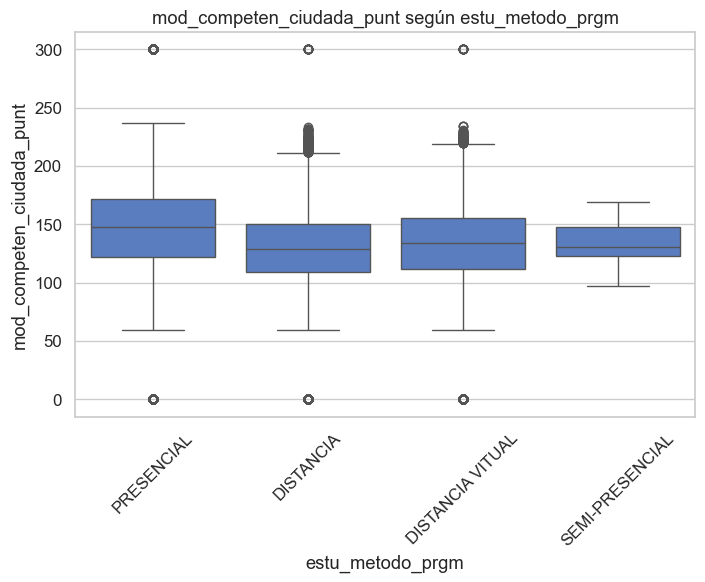

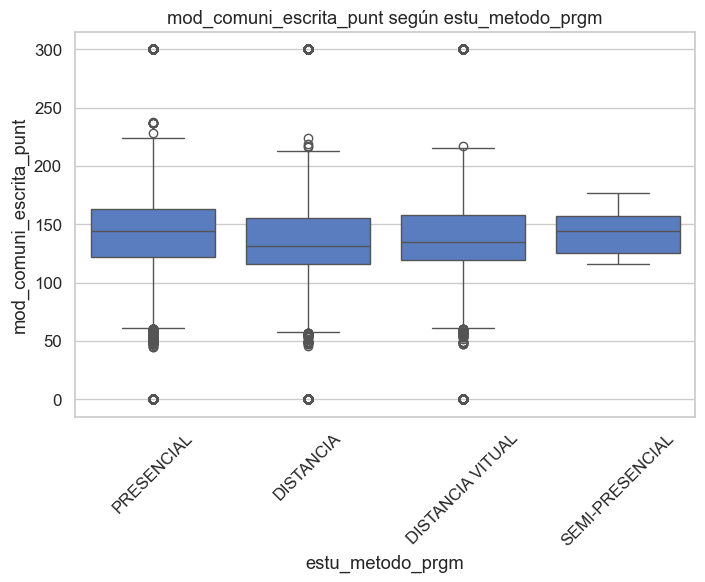

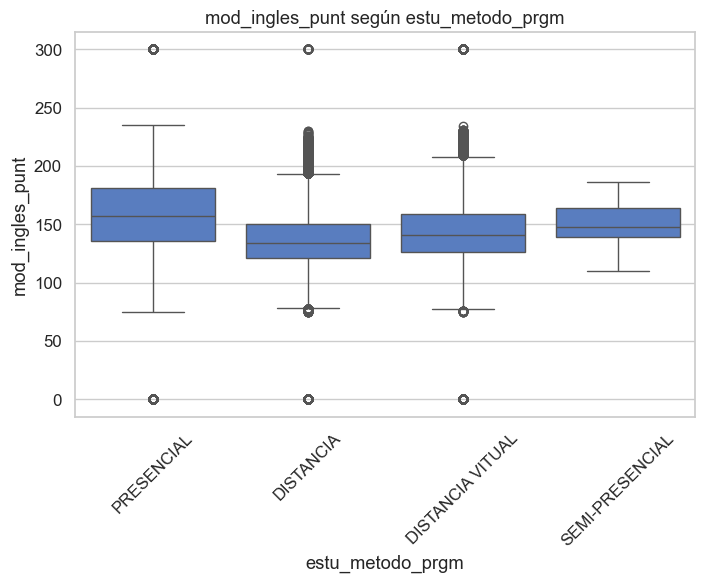

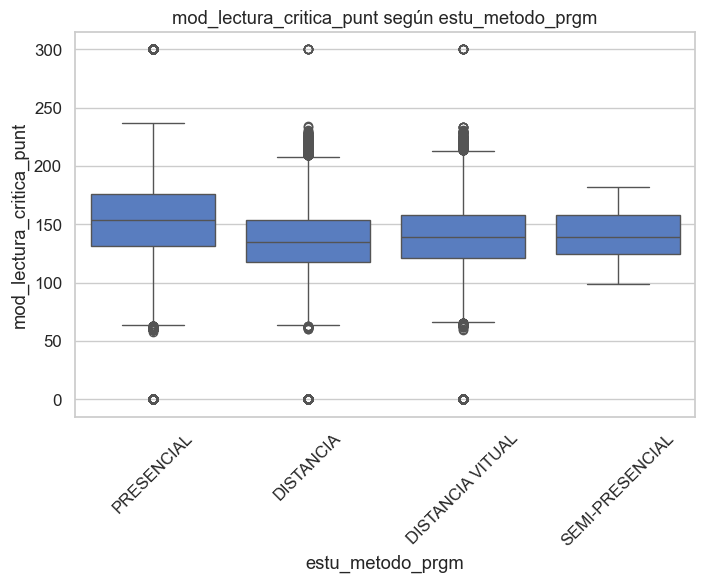

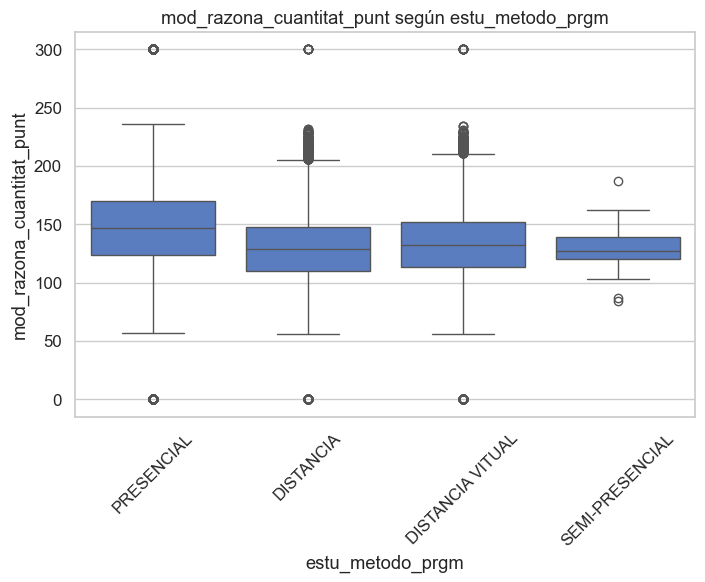

ANOVA para mod_competen_ciudada_punt ~ estu_metodo_prgm: F=11505.940, p=0

--- estu_nucleo_pregrado ---
                                                   mod_competen_ciudada_punt  \
                                                                        mean   
estu_nucleo_pregrado                                                           
ADMINISTRACIÓN                                                    135.749568   
AGRONOMÍA                                                         132.861361   
ANTROPOLOGÍA, ARTES LIBERALES                                     170.465176   
ARQUITECTURA                                                      144.008032   
ARTES PLÁSTICAS, VISUALES Y AFINES                                151.037495   
ARTES REPRESENTATIVAS                                             146.177180   
BACTERIOLOGÍA                                                     152.332712   
BIBLIOTECOLOGÍA, OTROS DE CIENCIAS SOCIALES Y H...                142.187192   
BIOLOGÍA, MICROB

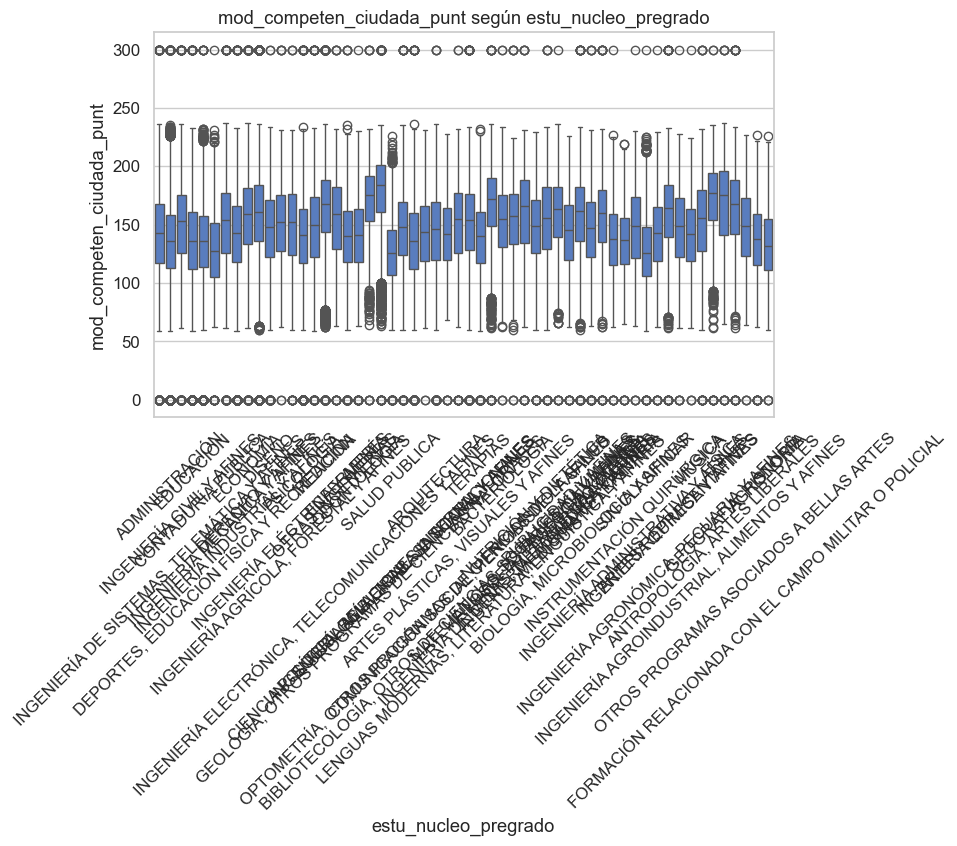

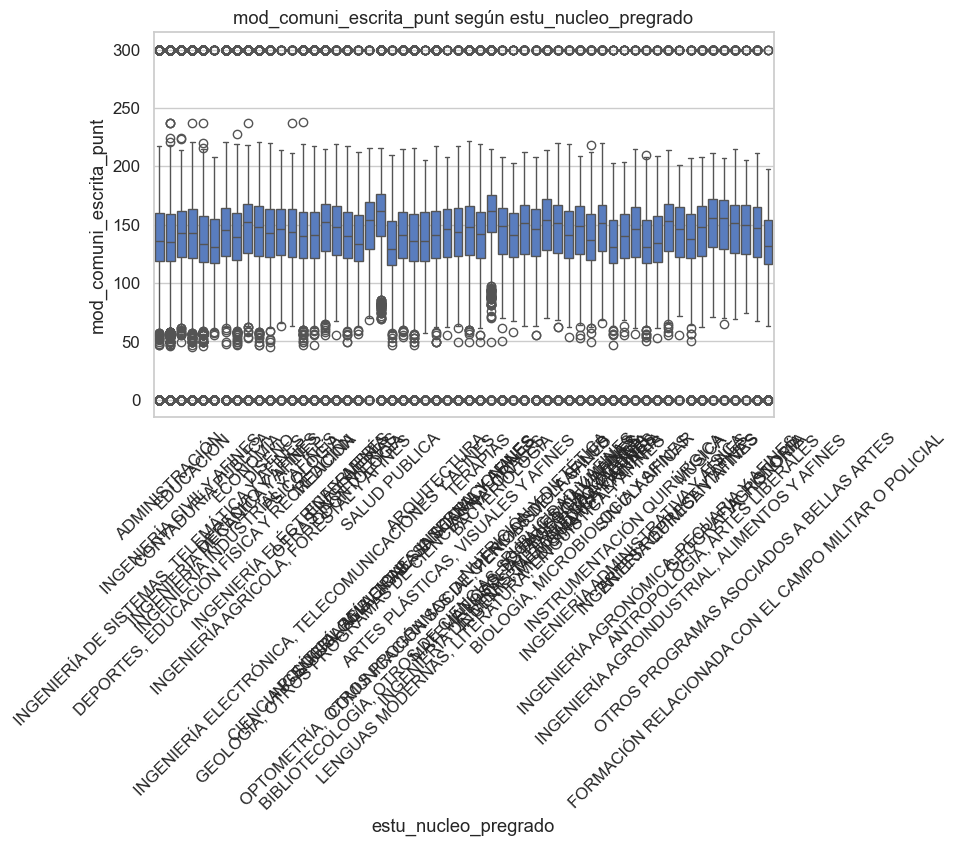

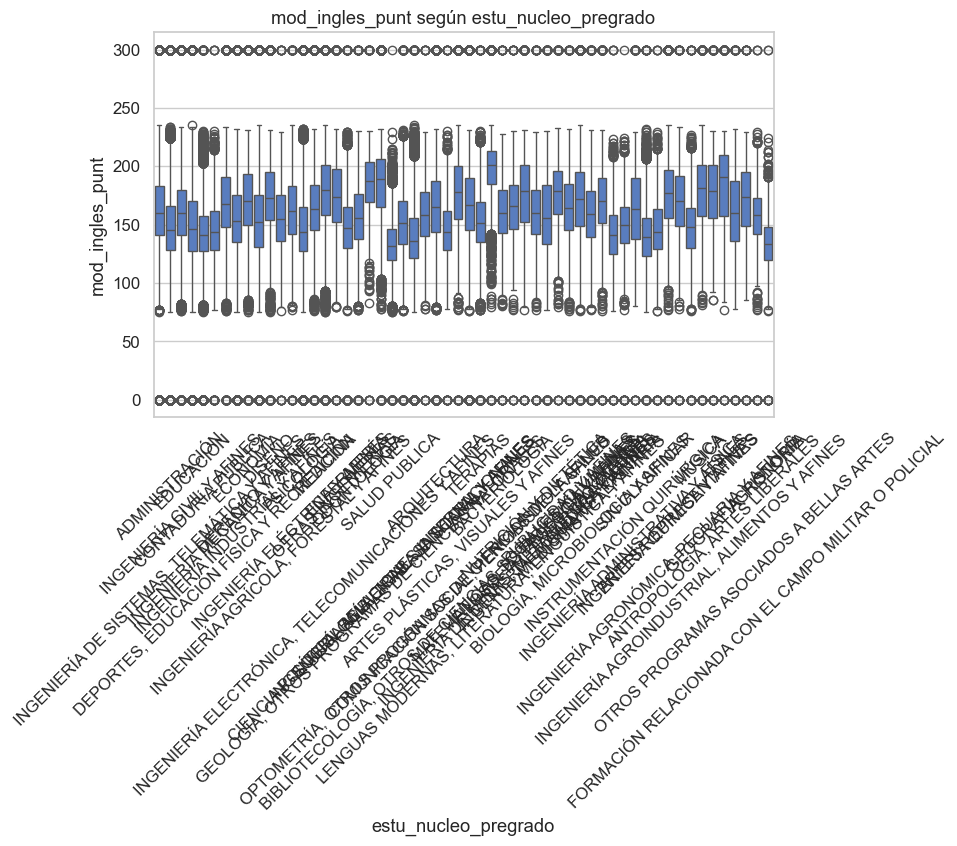

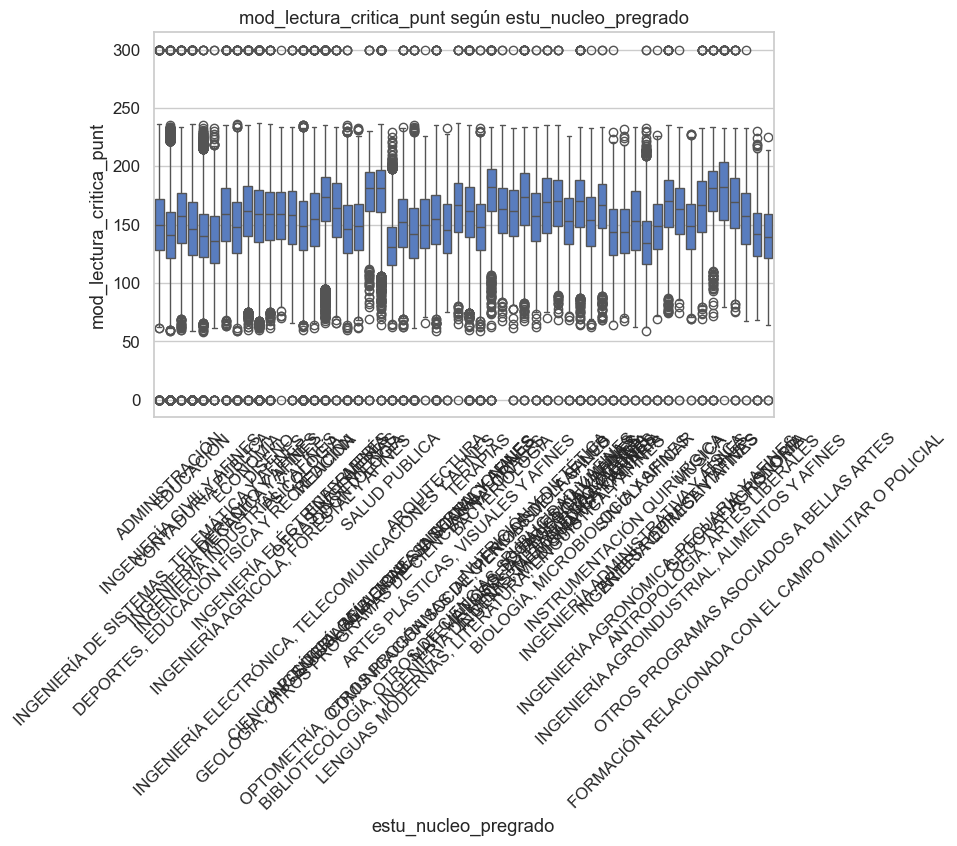

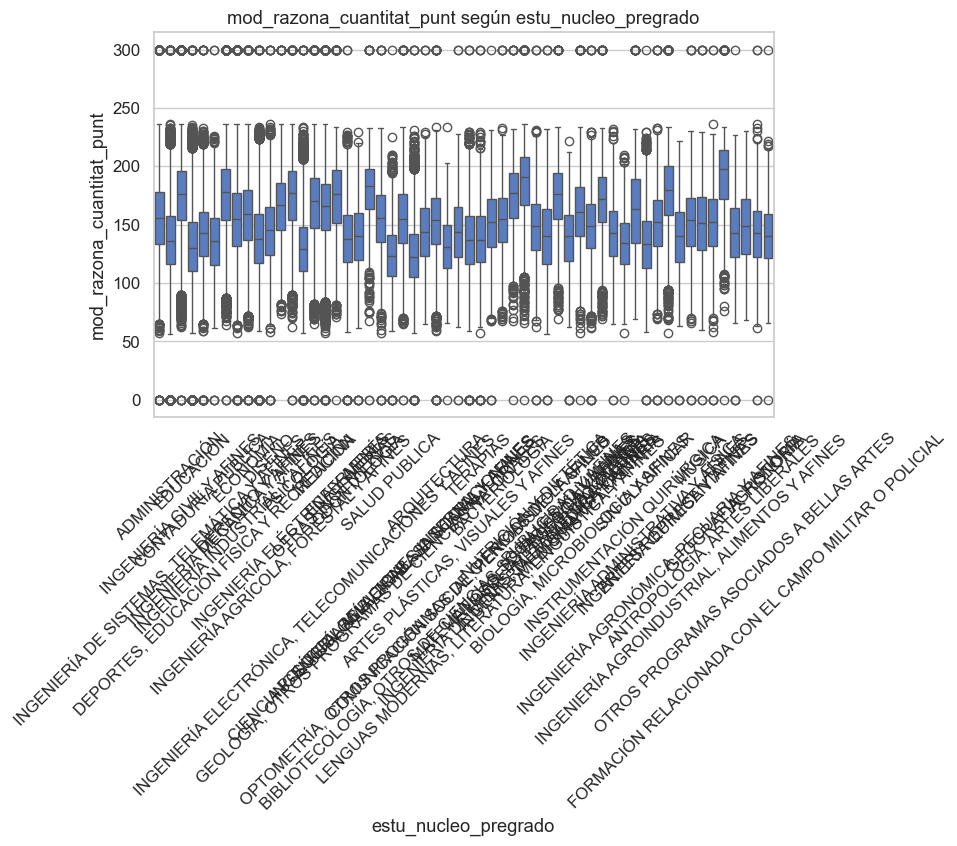

ANOVA para mod_competen_ciudada_punt ~ estu_nucleo_pregrado: F=1530.912, p=0


In [ ]:

## d) dim_programa
comparar_puntajes(fact, dim_programa, "id_programa", "estu_nivel_prgm_academico", puntajes)
comparar_puntajes(fact, dim_programa, "id_programa", "estu_metodo_prgm", puntajes)
comparar_puntajes(fact, dim_programa, "id_programa", "estu_nucleo_pregrado", puntajes)


**Nivel del programa académico vs puntajes**
La tabla está extremadamente desbalanceada (casi todo “Universitario”; “Tecnología” y “Técnico profesional” con n ínfimo), por lo que sus medias son inestables y no permiten comparar con fiabilidad. Aun con esa salvedad, el patrón es consistente: Universitario se ubica arriba en todos los módulos, con separación más visible en Inglés y Lectura, y más moderada en Ciudadana, Cuantitativo y Escrita.

**Método de formación del programa vs puntajes**
En conjunto, el componente **presencial** muestra los mejores resultados: las medianas e IQR se desplazan hacia arriba en todos los módulos (especialmente en **Inglés**, **Lectura** y **Cuantitativo**). **Distancia** y **distancia virtual** se sitúan por debajo de forma consistente (virtual suele quedar levemente por encima de distancia) y concentran más valores bajos. El esquema **semipresencial** se acerca a presencial y en **Escritura** incluso lo iguala o supera puntualmente, aunque con muestra pequeña, por lo que conviene cautela. Pese a estas tendencias, hay solapamiento entre métodos: el formato ayuda, pero la calidad del proceso y los recursos del estudiante siguen siendo determinantes del desempeño.

**Núcleo del programa de pregrado vs puntajes**
Por áreas se observan perfiles nítidos: los programas afines a lenguajes, comunicación y ciencias sociales sobresalen en Lectura crítica y Comunicación escrita, y también muestran buen desempeño en Inglés. Las disciplinas cuantitativas —Matemáticas y Estadística, Economía e Ingenierías, junto con Física— lideran en Razonamiento cuantitativo y mantienen resultados competitivos en Competencias ciudadanas. Las áreas de la salud (Medicina, Odontología, Enfermería, Bacteriología, etc.) exhiben un patrón equilibrado de medio a alto en todos los módulos, sin picos tan marcados como en Ingenierías para Cuantitativo ni tan altos como en Humanidades para Lectura/Escrita. Administración, Contaduría y Derecho tienden a ubicarse alrededor del promedio con variabilidad apreciable entre instituciones, mientras que Artes y Diseño presentan la mayor dispersión (conviven desempeños muy altos y muy bajos), señal de gran heterogeneidad formativa.


--- anio ---
     mod_competen_ciudada_punt                    mod_comuni_escrita_punt  \
                          mean        std   count                    mean   
anio                                                                        
2021                143.068609  35.227480  253568              137.173516   
2022                143.428343  34.769740  231030              129.207653   
2023                139.372395  34.324766  249096              140.405398   
2024                145.224484  32.968639  281601              133.641915   

                        mod_ingles_punt                     \
            std   count            mean        std   count   
anio                                                         
2021  40.744878  253568      153.579383  34.548073  253447   
2022  51.903619  231030      154.694540  35.324184  230904   
2023  39.150184  249096      152.874263  33.623391  248941   
2024  45.265529  281601      154.964503  34.153793  281430   

     mod_le

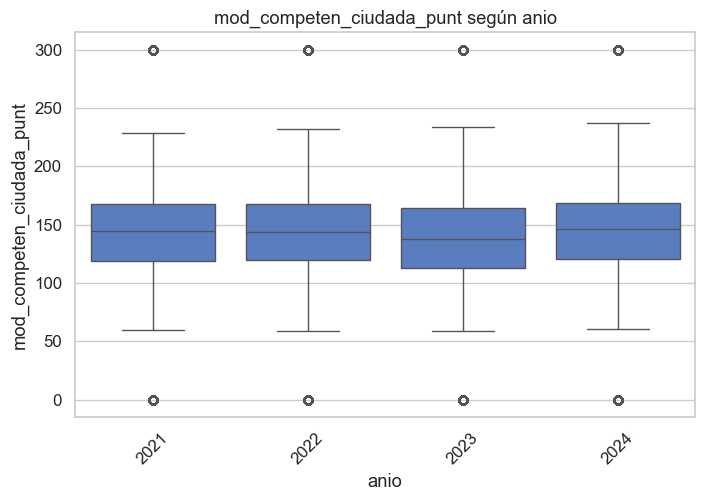

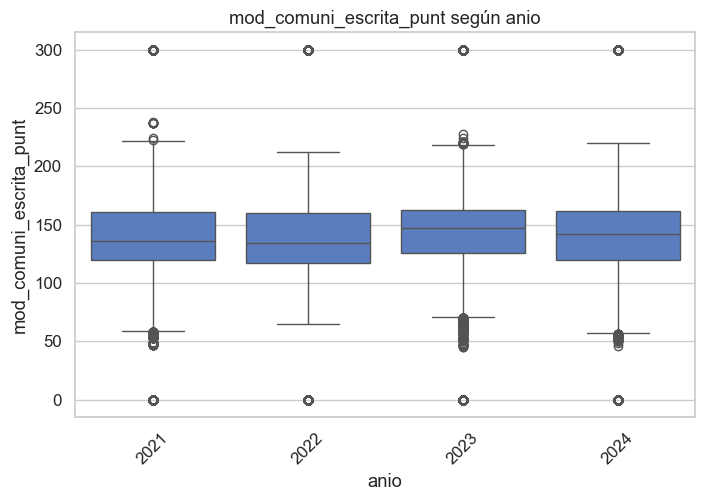

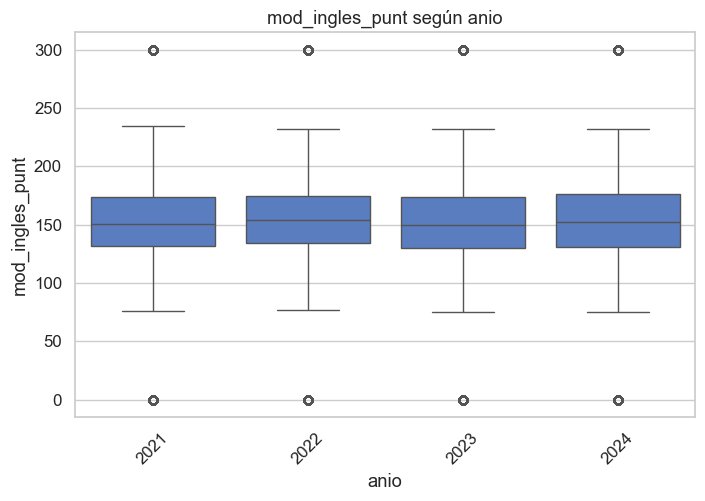

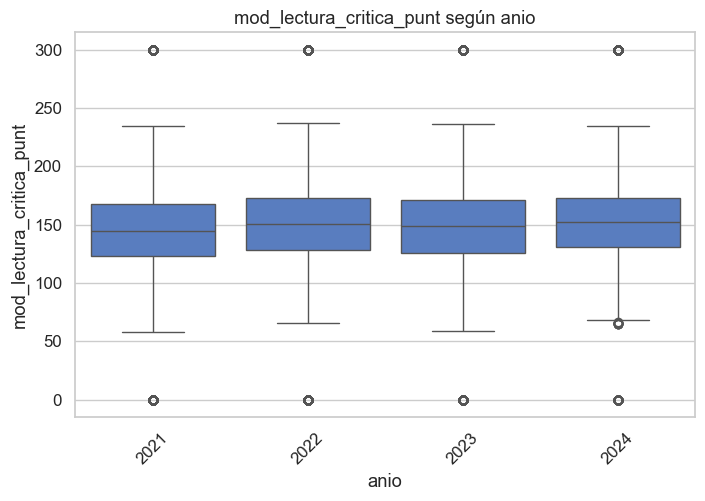

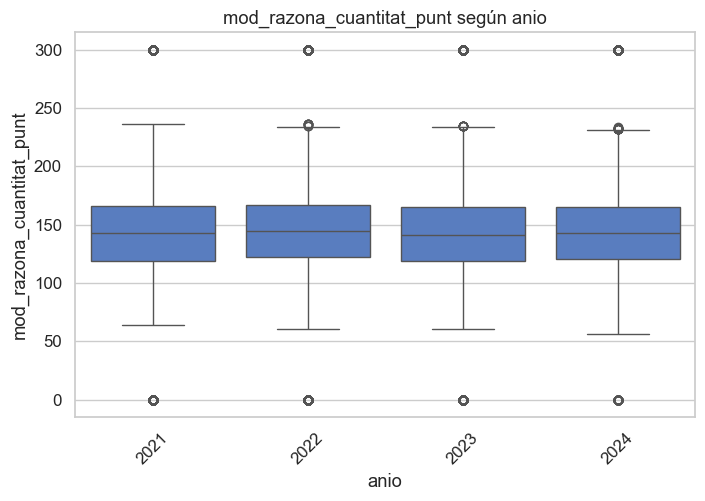

ANOVA para mod_competen_ciudada_punt ~ anio: F=1329.738, p=0

--- periodo ---
        mod_competen_ciudada_punt                    mod_comuni_escrita_punt  \
                             mean        std   count                    mean   
periodo                                                                        
20212                  143.019016  35.167878  251894              137.151020   
20213                  150.531063  42.630278    1674              140.558542   
20222                  144.254206  34.390262  101465              125.914729   
20223                  145.657270  38.666322     674              136.596439   
20225                  142.647040  34.966620  127822              131.816424   
20226                  157.057063  39.436546    1069              125.164640   
20231                  136.727031  34.155683  140939              142.880246   
20232                  152.318204  38.322173    2093              157.676541   
20233                  142.525778  34.1049

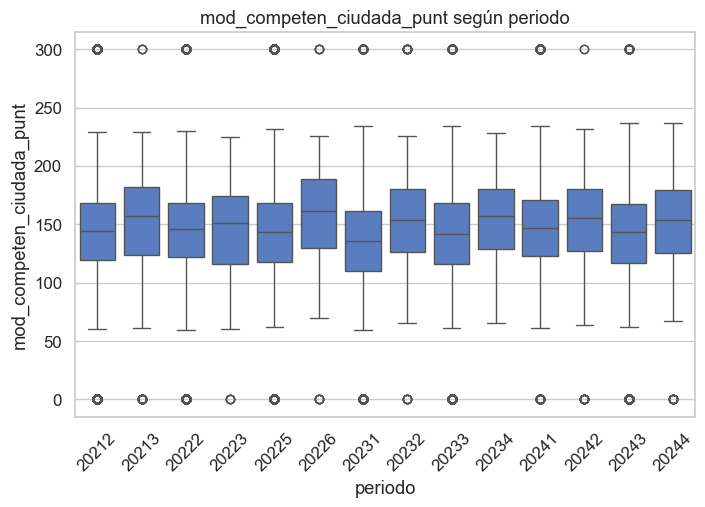

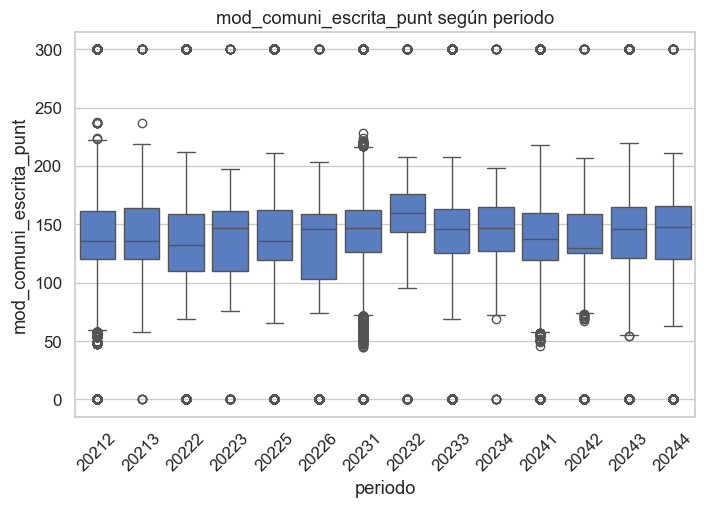

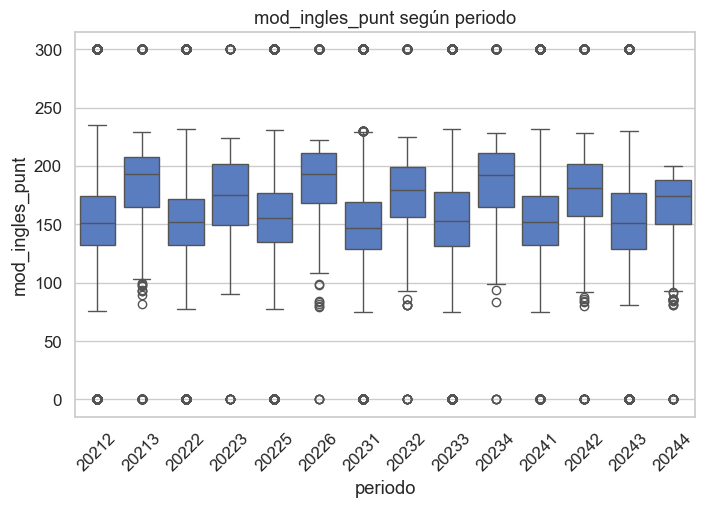

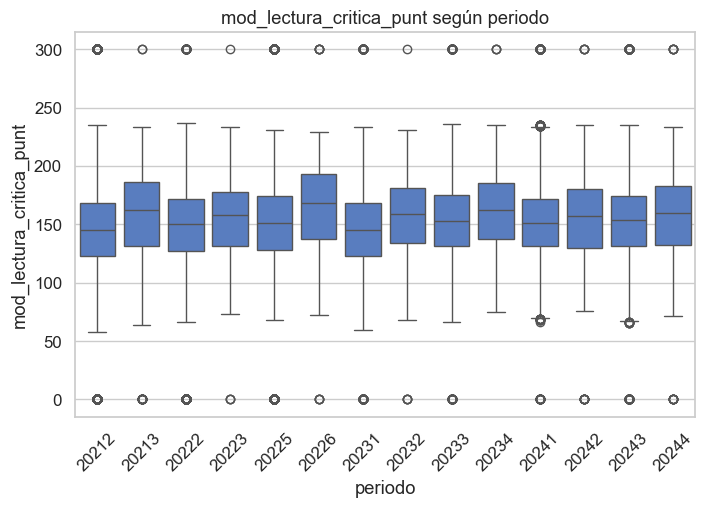

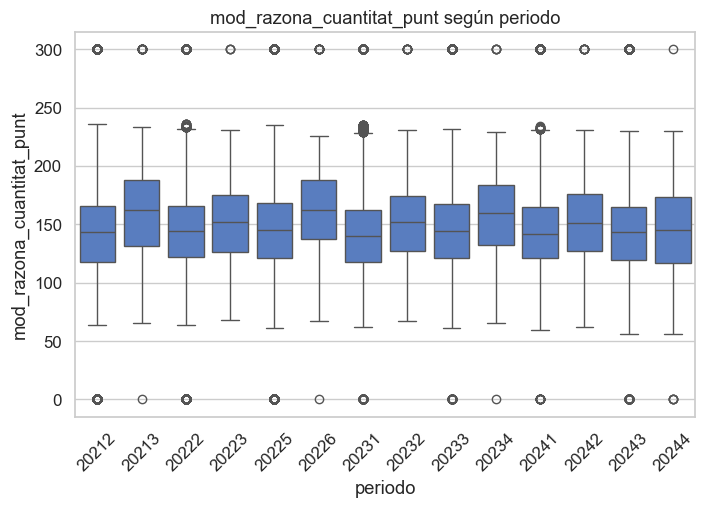

ANOVA para mod_competen_ciudada_punt ~ periodo: F=602.417, p=0


In [ ]:

## e) dim_tiempo
comparar_puntajes(fact, dim_tiempo, "id_tiempo", "anio", puntajes)
comparar_puntajes(fact, dim_tiempo, "id_tiempo", "periodo", puntajes)

**Puntajes por año (2021–2024)**
Los módulos se mantienen **estables** año a año, con **fluctuaciones leves**: se insinúa un **bache en 2023** y un **ajuste al alza en 2024**. **Inglés** es el más dinámico (recupera más rápido), **Lectura** acompaña con mejoras suaves, **Cuantitativo** sube de forma contenida y **Escritura** se mantiene como el módulo más bajo. La **dispersión** cambia poco entre años, lo que sugiere que el patrón de desempeño es robusto y que los cambios anuales reflejan ajustes de cohorte más que rupturas estructurales.

**Puntajes por período (20212–20244)**
Dentro de cada año hay una **estacionalidad moderada**: los puntajes **bajan al inicio** y **mejoran hacia los cierres** de periodo, con **picos intermedios** en algunos cortes y **valles** en los primeros. **Inglés y Lectura** concentran la mayor parte de los repuntes; **Cuantitativo** y **Escritura** muestran trayectorias más **planas**, aunque acompañan la tendencia general. Aun con estas ondas, los **rangos intercuartílicos** son parecidos entre periodos y el **orden relativo entre módulos** se conserva, indicando que las variaciones intra-anuales afectan el nivel, pero no cambian el patrón de desempeño.



--- estu_genero vs fami_tieneinternet ---
fami_tieneinternet        No        Si
estu_genero                           
F                   0.114765  0.885235
M                   0.099676  0.900324
All                 0.108431  0.891569


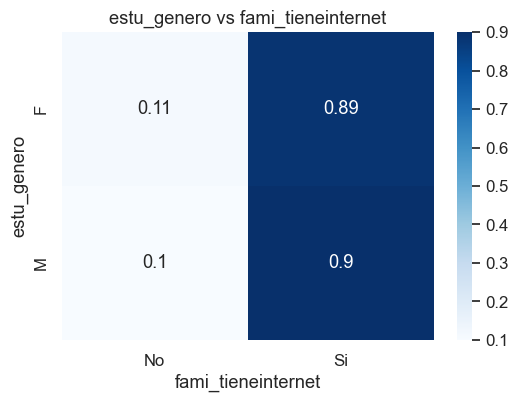

Chi2=564.501, p=8.82e-125, dof=1

--- estu_genero vs fami_estratovivienda ---
fami_estratovivienda  Estrato 1  Estrato 2  Estrato 3  Estrato 4  Estrato 5  \
estu_genero                                                                   
F                      0.222751   0.363324   0.285434   0.081169   0.027677   
M                      0.187418   0.347445   0.308927   0.097034   0.034366   
All                    0.207921   0.356659   0.295294   0.087828   0.030484   

fami_estratovivienda  Estrato 6  Sin Estrato  
estu_genero                                   
F                      0.014975     0.004672  
M                      0.019124     0.005685  
All                    0.016716     0.005097  


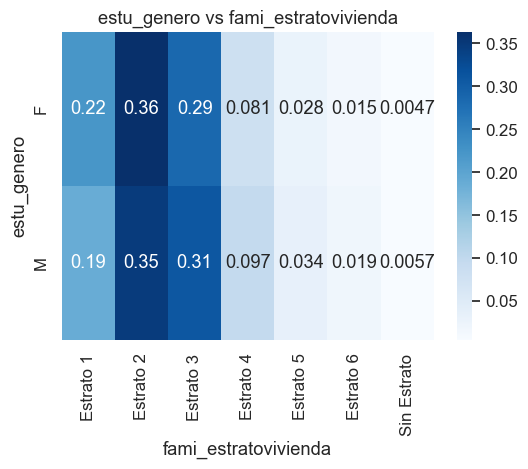

Chi2=3372.743, p=0, dof=6

--- estu_etnia vs fami_educacionmadre ---
fami_educacionmadre  Educación profesional completa  \
estu_etnia                                            
Achagua                                    0.000000   
Afrodescendiente                           0.131293   
Ambalo                                     0.153846   
Amorúa                                     0.300000   
Andoque                                    0.500000   
...                                             ...   
Yuko (Yukpa)                               0.000000   
Yuri                                       0.000000   
Yuruti (Tapuya)                            0.250000   
Zenu (Senu)                                0.114223   
All                                        0.088475   

fami_educacionmadre  Educación profesional incompleta   Ninguno  No Aplica  \
estu_etnia                                                                   
Achagua                                      0.000000  0.00

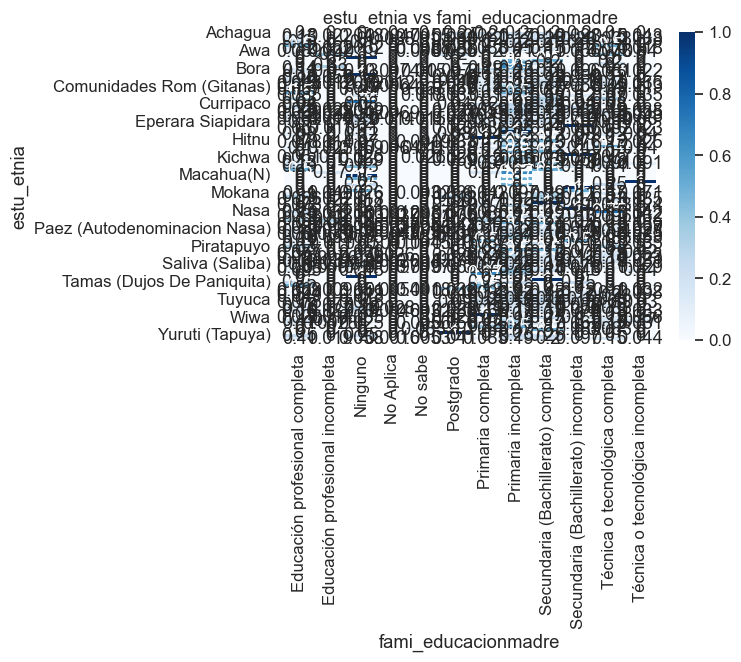

Chi2=5843.516, p=0, dof=1133

--- estu_etnia vs fami_educacionpadre ---
fami_educacionpadre  Educación profesional completa  \
estu_etnia                                            
Achagua                                    0.200000   
Afrodescendiente                           0.117478   
Ambalo                                     0.115385   
Amorúa                                     0.200000   
Andoque                                    0.000000   
...                                             ...   
Yuko (Yukpa)                               0.083333   
Yuri                                       1.000000   
Yuruti (Tapuya)                            0.250000   
Zenu (Senu)                                0.128651   
All                                        0.089487   

fami_educacionpadre  Educación profesional incompleta   Ninguno  No Aplica  \
estu_etnia                                                                   
Achagua                                      0.000000  0

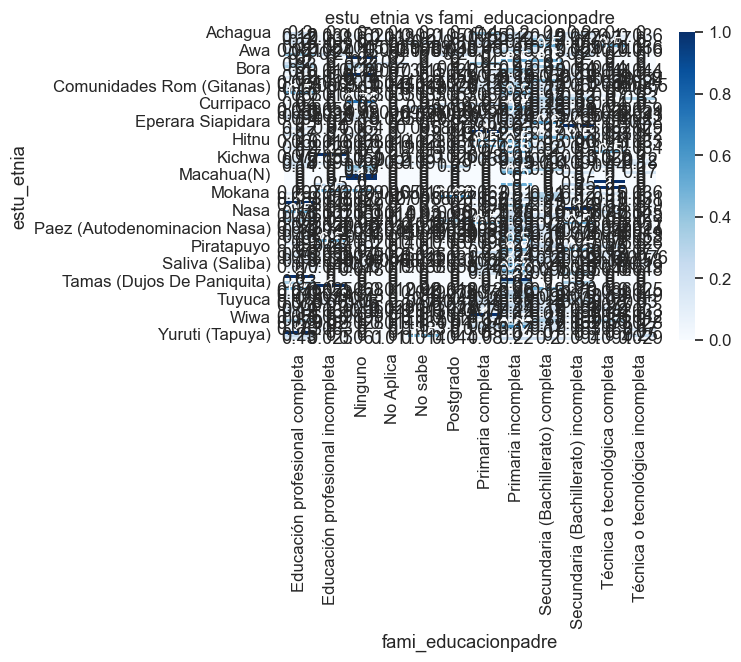

Chi2=3968.178, p=3.59e-310, dof=1133


In [ ]:

## a) dim_estudiante y dim_familia
analizar_categoricas(fact.merge(dim_estudiante, on="id_estudiante"), dim_familia, "id_familia", "estu_genero", "fami_tieneinternet")
analizar_categoricas(fact.merge(dim_estudiante, on="id_estudiante"), dim_familia, "id_familia", "estu_genero", "fami_estratovivienda")
analizar_categoricas(fact.merge(dim_estudiante, on="id_estudiante"), dim_familia, "id_familia", "estu_etnia", "fami_educacionmadre")
analizar_categoricas(fact.merge(dim_estudiante, on="id_estudiante"), dim_familia, "id_familia", "estu_etnia", "fami_educacionpadre")


**Relación Género con Tener internet en casa:** Al cruzar género con tener internet en casa, se ve que en ambos grupos alrededor de 9 de cada 10 estudiantes sí tienen internet. Los hombres aparecen con acceso apenas un poco mayor que las mujeres, y ellas concentran un poco más de no tiene internet en casa. La prueba estadística detecta diferencia, pero es pequeña y no cambia mucho la distribución entre géneros.

**Relación Género con estrato de Vivienda:** Al cruzar género con estrato de vivienda, ambos géneros se concentran sobre todo en estratos 2 y 3; luego viene el estrato 1, y a partir del 4 la participación baja bastante. Los estratos 5 y 6 son minoritarios para todos. La diferencia entre géneros es leve pero consistente: las mujeres tienen un poco más de presencia en estratos 1–2, mientras que los hombres pesan un poco más en estratos 3–6.


--- inst_caracter_academico vs estu_metodo_prgm ---
estu_metodo_prgm           DISTANCIA  DISTANCIA VITUAL  PRESENCIAL  \
inst_caracter_academico                                              
INSTITUCIÓN TECNOLÓGICA     0.001391          0.019365    0.979244   
INSTITUCIÓN UNIVERSITARIA   0.209486          0.198561    0.591953   
TÉCNICA PROFESIONAL         0.039447          0.292838    0.667026   
UNIVERSIDAD                 0.099964          0.027409    0.872627   
All                         0.133409          0.093450    0.773124   

estu_metodo_prgm           SEMI-PRESENCIAL  
inst_caracter_academico                     
INSTITUCIÓN TECNOLÓGICA           0.000000  
INSTITUCIÓN UNIVERSITARIA         0.000000  
TÉCNICA PROFESIONAL               0.000689  
UNIVERSIDAD                       0.000000  
All                               0.000016  


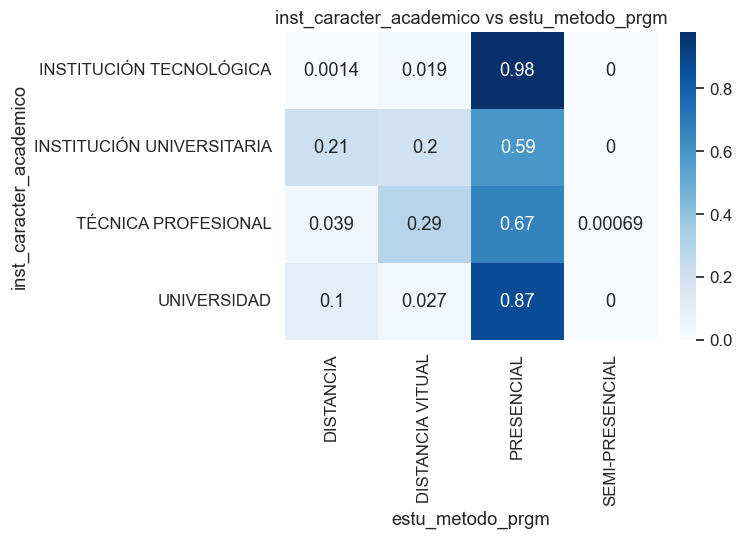

Chi2=131459.219, p=0, dof=9

--- inst_origen vs estu_nivel_prgm_academico ---
estu_nivel_prgm_academico  TECNOLOGÍA  TÉCNICO PROFESIONAL  UNIVERSITARIO
inst_origen                                                              
NO OFICIAL - CORPORACIÓN     0.000000             0.000003       0.999997
NO OFICIAL - FUNDACIÓN       0.000003             0.000000       0.999997
OFICIAL DEPARTAMENTAL        0.000006             0.000000       0.999994
OFICIAL MUNICIPAL            0.000040             0.000000       0.999960
OFICIAL NACIONAL             0.000006             0.000006       0.999988
REGIMEN ESPECIAL             0.000000             0.000000       1.000000
All                          0.000004             0.000002       0.999994


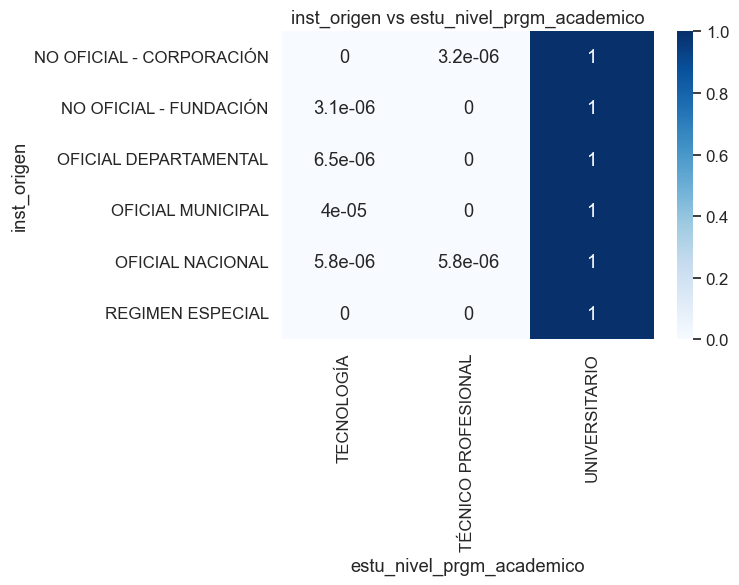

Chi2=12.230, p=0.27, dof=10


In [ ]:

## b) dim_institucion y dim_programa
analizar_categoricas(dim_institucion, fact.merge(dim_programa, on="id_programa"), "id_institucion", "inst_caracter_academico", "estu_metodo_prgm")
analizar_categoricas(dim_institucion, fact.merge(dim_programa, on="id_programa"), "id_institucion", "inst_origen", "estu_nivel_prgm_academico")


**Relación tipo de institución con método del programa:** Al cruzar tipo de institución con método del programa se ve que la modalidad presencial domina en todos los casos, pero con diferencias claras según la institución. En la institución tecnológica casi todo es presencial prácticamente la totalidad. En la universidad también predomina lo presencial alrededor de ocho de cada diez. En la institución universitaria el esquema es más mixto: cerca de seis de cada diez son presenciales y una parte importante se reparte entre distancia y virtual. En la técnica profesional hay dos tercios presenciales y casi tres de cada diez en virtual. La semipresencial casi no aparece. La prueba confirma que el método cambia según el tipo de institución.

**Relación Origen de la institución con Nivel del Programa:** Al cruzar origen de la institución con nivel del programa, se ve que casi todo está en nivel universitario, sin importar si la institución es oficial como nacional, municipal, departamental, o no oficial como fundación, corporación, o de régimen especial. Los niveles tecnológico y técnico profesional aparecen solo con participaciones mínimas. La prueba estadística con un resultado de p = 0.27 indica que no hay una relación clara entre el origen y el nivel del programa.


--- fami_estratovivienda vs inst_caracter_academico ---
inst_caracter_academico  INSTITUCIÓN TECNOLÓGICA  INSTITUCIÓN UNIVERSITARIA  \
fami_estratovivienda                                                          
Estrato 1                               0.038542                   0.328024   
Estrato 2                               0.043824                   0.394776   
Estrato 3                               0.037187                   0.382694   
Estrato 4                               0.018895                   0.243018   
Estrato 5                               0.007357                   0.161064   
Estrato 6                               0.004891                   0.126741   
Sin Estrato                             0.033754                   0.309588   
All                                     0.036734                   0.351773   

inst_caracter_academico  TÉCNICA PROFESIONAL  UNIVERSIDAD  
fami_estratovivienda                                       
Estrato 1                       

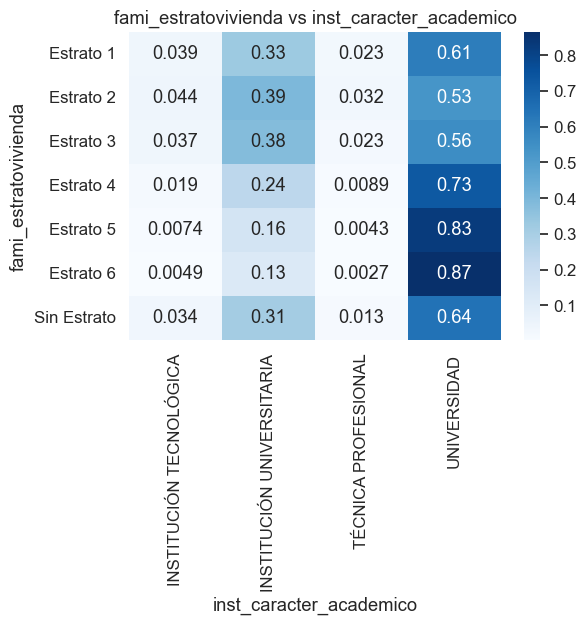

Chi2=26352.126, p=0, dof=18

--- fami_tienecomputador vs inst_caracter_academico ---
inst_caracter_academico  INSTITUCIÓN TECNOLÓGICA  INSTITUCIÓN UNIVERSITARIA  \
fami_tienecomputador                                                          
No                                      0.046544                   0.350542   
Si                                      0.035719                   0.351733   
All                                     0.036978                   0.351594   

inst_caracter_academico  TÉCNICA PROFESIONAL  UNIVERSIDAD  
fami_tienecomputador                                       
No                                  0.029806     0.573108  
Si                                  0.023223     0.589326  
All                                 0.023988     0.587440  


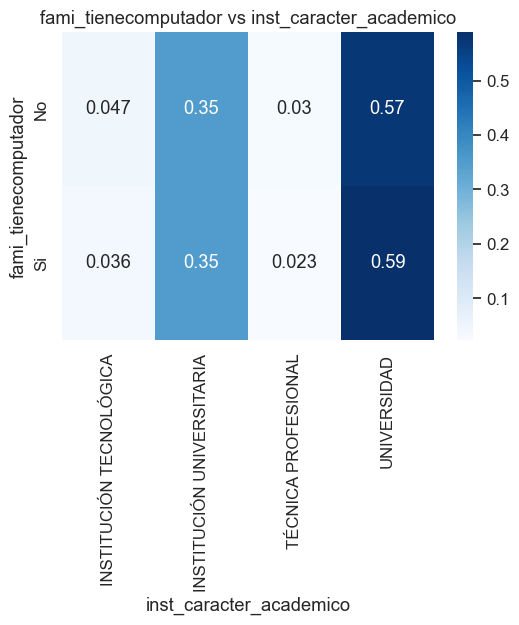

Chi2=526.678, p=7.89e-114, dof=3


In [ ]:

## c) dim_familia y dim_institucion
analizar_categoricas(fact.merge(dim_familia, on="id_familia"), dim_institucion, "id_institucion", "fami_estratovivienda", "inst_caracter_academico")
analizar_categoricas(fact.merge(dim_familia, on="id_familia"), dim_institucion, "id_institucion", "fami_tienecomputador", "inst_caracter_academico")


**Relación estrato de vivienda con carácter académico de la institución:** Al cruzar estrato de vivienda con carácter académico de la institución, se ve que la universidad es mayoría en todos los estratos. En estrato 1 cerca del 61% está en universidad y ese porcentaje crece a medida que sube el estrato, llegando a alrededor del 87% en estrato 6. En cambio, las instituciones universitarias y tecnológicas tienen más peso en los estratos bajos y van perdiendo participación en los estratos altos; la técnica profesional es minoritaria en todos los casos. La prueba estadística confirma que sí hay diferencias claras por estrato pues cambian las proporciones según el nivel socioeconómico.

**Relación tiene computador con carácter académico de la institución:** Al cruzar tener computador en casa con el tipo de institución, en ambos casos la mayoría de estudiantes está en universidad. Tener computador se asocia con una ligera mayor presencia en universidad y una ligera menor presencia en tecnológicas/técnicas; en institución universitaria casi no hay diferencia. La prueba estadística confirma que sí hay diferencias, pero son pequeñas y no cambian mucho la distribución entre tipos de institución.

Relación entre periodo y método del programa


--- periodo vs estu_metodo_prgm ---
estu_metodo_prgm  DISTANCIA  DISTANCIA VITUAL  PRESENCIAL  SEMI-PRESENCIAL
periodo                                                                   
20212              0.152499          0.075895    0.771606         0.000000
20213              0.083035          0.186977    0.729988         0.000000
20222              0.155509          0.105265    0.739225         0.000000
20223              0.121662          0.324926    0.553412         0.000000
20225              0.117982          0.071037    0.810981         0.000000
20226              0.048644          0.165575    0.785781         0.000000
20231              0.133971          0.114092    0.751937         0.000000
20232              0.092690          0.223602    0.683708         0.000000
20233              0.108477          0.061835    0.829688         0.000000
20234              0.061955          0.148112    0.789932         0.000000
20241              0.131799          0.124372    0.743766      

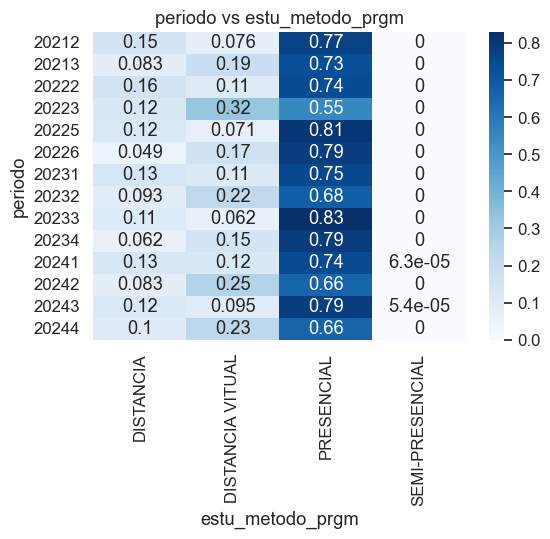

Chi2=10351.924, p=0, dof=39


In [ ]:
## d) dim_tiempo
analizar_categoricas(dim_tiempo, fact.merge(dim_programa, on="id_programa"), "id_tiempo", "periodo", "estu_metodo_prgm")

La relación entre periodo y método del programa deja claro que la modalidad presencial es la más común en todo el tiempo, con participaciones entre 66% y 83%. En 20223 se ve una bajada fuerte del presencial, cerca del 55%, al mismo tiempo que sube la virtual hasta alrededor del 32%. Entre 20225 y 20234 el presencial vuelve a dominar, cerca del 80%. En 20242–20244 otra vez cae el presencial hasta 66% y la virtual crece a 23–25%. La distancia tradicional se mantiene estable entre 10% y 16%, y la semipresencial es casi nula. La prueba chi-cuadrado indica que sí hay diferencias por periodo dado que las proporciones no son iguales en todos los años.

## Análisis Multivariado

In [ ]:
# Cargar dimensión familia
dim_familia = pd.read_sql("SELECT * FROM dim_familia", conn)

# Merge con dimensiones
df_merge = (
    fact
    .merge(
        pd.read_sql("SELECT id_estudiante, estu_genero FROM dim_estudiante", conn),
        on="id_estudiante", how="left"
    )
    .merge(
        pd.read_sql("SELECT id_institucion, inst_caracter_academico FROM dim_institucion", conn),
        on="id_institucion", how="left"
    )
    .merge(
        pd.read_sql("SELECT id_programa, estu_nivel_prgm_academico FROM dim_programa", conn),
        on="id_programa", how="left"
    )
    .merge(dim_familia, on="id_familia", how="left")
)

# Variables categóricas
cat_vars = [
    'fami_estratovivienda', 'fami_educacionpadre', 'fami_educacionmadre', 'fami_tieneinternet',
    'fami_tienecomputador',"estu_genero", "inst_caracter_academico", "estu_nivel_prgm_academico"
]
# Variables numéricas
num_vars = [
    "mod_competen_ciudada_punt",
    "mod_comuni_escrita_punt",
    "mod_ingles_punt",
    "mod_lectura_critica_punt",
    "mod_razona_cuantitat_punt"
]

# Subconjunto para FAMD
df_famd = df_merge[num_vars + cat_vars].dropna()

# Ajustar modelo FAMD
famd = prince.FAMD(
    n_components=7,
    n_iter=3,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=123
)

famd = famd.fit(df_famd)

Varianza explicada por componente 📊

In [ ]:
# Varianza explicada
print("Varianza explicada por componente:")
print(famd.eigenvalues_summary)


Varianza explicada por componente:
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              9.844         6.61%                      6.61%
1              6.414         4.30%                     10.91%
2              5.537         3.72%                     14.63%
3              5.219         3.50%                     18.13%
4              5.110         3.43%                     21.56%
5              4.938         3.31%                     24.87%
6              4.700         3.15%                     28.03%


En la FAMD, una sola dimensión explica 6,61% de la información; con dos se llega a 10,91%; con tres, a 14,63%; y con siete, a 28,03%. Esto indica que la información está distribuida en varias dimensiones y no concentrada en una sola. Por eso, el plano con Dim1–Dim2 nos sirve para ver tendencias generales y grupos grandes, pero no alcanza para contar todo; para un análisis completo conviene mirar más dimensiones y apoyarse en otras tablas (por ejemplo, contribución de variables a cada dimensión, promedios de puntajes por categoría y tamaños de muestra).

Gráfico de Individuos 📈

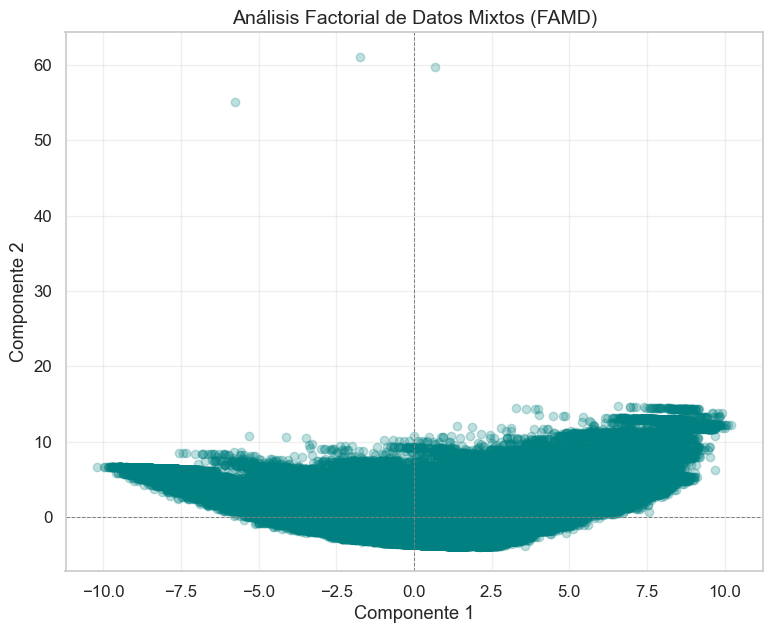

In [ ]:
# Coordenadas de los individuos
row_coords = famd.row_coordinates(df_famd)

# Gráfico de individuos
plt.figure(figsize=(9,7))
plt.scatter(row_coords[0], row_coords[1], alpha=0.25, c="teal")
plt.title("Análisis Factorial de Datos Mixtos (FAMD)", fontsize=14)
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.axhline(0, color="grey", linestyle="--", linewidth=0.7)
plt.axvline(0, color="grey", linestyle="--", linewidth=0.7)
plt.grid(alpha=0.3)
plt.show()

Al ver el gráfico de individuos, los puntos observados es decir los estudiantes forman una sola nube, sin grupos separados. Esa nube se alarga más de izquierda a derecha como se observa en la Dimensión 1 y cambia poco de abajo hacia arriba (Dimensión 2). Solo hay unos pocos puntos muy alejados, que parecen casos extremos. En conclusión el plano ofrece una buena vista general, pero para conclusiones más precisas conviene revisar también otras dimensiones.

Biplot de variables (FAMD) 📉

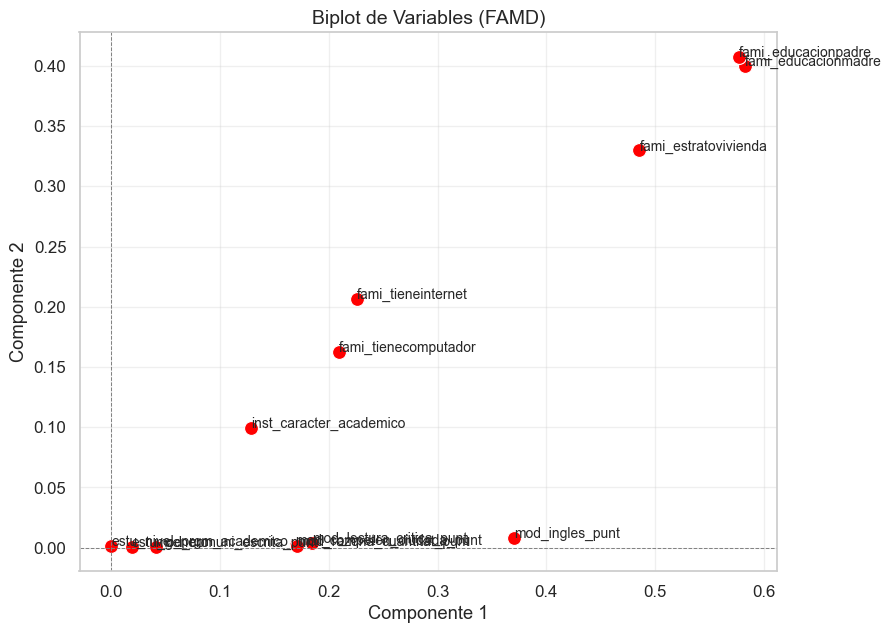

In [ ]:
col_coords = famd.column_coordinates_

plt.figure(figsize=(9,7))
sns.scatterplot(x=col_coords[0], y=col_coords[1], s=100, color="red")

# Etiquetas de variables
for i, var in enumerate(col_coords.index):
    plt.text(col_coords.iloc[i,0], col_coords.iloc[i,1], var, fontsize=10)

plt.title("Biplot de Variables (FAMD)", fontsize=14)
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.axhline(0, color="grey", linestyle="--", linewidth=0.7)
plt.axvline(0, color="grey", linestyle="--", linewidth=0.7)
plt.grid(alpha=0.3)
plt.show()

En este biplot se ve qué variables jalan más el mapa. Las que más pesan son el estrato de vivienda y la educación de la madre y del padre; también cuentan si la familia tiene internet y tiene computador. Todas quedan hacia el lado derecho y un poco arriba, así que la Dimensión 1 puede leerse como un eje socioeconómico/educativo se podría decir que a mayor estrato y mayor educación de los padres, más se ubican los casos hacia ese lado. En ese mismo sentido aparece el puntaje de Inglés, que se alinea sobre todo con la Dimensión 1. El resto de variables como género, nivel del programa, carácter académico y los otros puntajes, queda cerca del centro, por lo que en este plano aportan poco